# Ahmed Abdelmoneim Kotb.                                   # 232000349.

# ♛ 4-Queens Problem — Depth First Search (Recursive)
### CAI3101 · Artificial Intelligence · Dr. Mohamed Farouk
### Arab Academy for Science and Technology

---

**Problem:** Place **4 queens** on a 4×4 chessboard so that **no two queens attack each other**.  
No two queens may share the same **row**, **column**, or **diagonal**.

**Algorithm:** Recursive Depth-First Search (DFS) with backtracking.

**Output format:** Binary matrix — `1` = queen placed, `0` = empty cell.

---


In [1]:
# ═══════════════════════════════════════════════════════════
#  IMPORTS
# ═══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme ─────────────────────────────────────────────
BG    = '#0d1117'
PANEL = '#161b22'
CARD  = '#21262d'
LINE  = '#30363d'
C = dict(
    white ='#f0f6fc', gray  ='#8b949e', blue  ='#58a6ff',
    green ='#3fb950', red   ='#f85149', yellow='#e3b341',
    purple='#bc8cff', teal  ='#39d353', orange='#f0883e',
    cyan  ='#79c0ff', pink  ='#ff7eb6',
)
PAL = [C['blue'], C['green'], C['yellow'], C['red'], C['purple'], C['orange']]

plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'text.color'      : C['white'],
    'axes.labelcolor' : C['white'],
    'xtick.color'     : C['gray'],
    'ytick.color'     : C['gray'],
    'axes.edgecolor'  : LINE,
    'axes.facecolor'  : PANEL,
    'figure.facecolor': BG,
    'grid.color'      : CARD,
    'grid.linewidth'  : 0.5,
})

def style(ax, title='', xl='', yl='', grid=False, legend=False):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(LINE)
    if title:  ax.set_title(title, color=C['white'], fontsize=10,
                             fontweight='bold', pad=8)
    if xl:     ax.set_xlabel(xl, color=C['gray'], fontsize=8)
    if yl:     ax.set_ylabel(yl, color=C['gray'], fontsize=8)
    if grid:   ax.grid(True, alpha=0.25, linestyle='--')
    if legend: ax.legend(facecolor=CARD, labelcolor=C['white'],
                          fontsize=8, framealpha=0.9)

print("✓ Libraries imported & theme applied")


✓ Libraries imported & theme applied


## 1 · DFS Algorithm — Implementation & Solution

In [2]:
# ═══════════════════════════════════════════════════════════
#  4-QUEENS  —  RECURSIVE DFS
# ═══════════════════════════════════════════════════════════
N = 4
all_solutions = []

def is_safe(board, row, col):
    """Return True if placing a queen at (row, col) is safe."""
    # Check same column in rows above
    for r in range(row):
        if board[r] == col:
            return False
    # Check upper-left diagonal
    r, c = row - 1, col - 1
    while r >= 0 and c >= 0:
        if board[r] == c: return False
        r -= 1; c -= 1
    # Check upper-right diagonal
    r, c = row - 1, col + 1
    while r >= 0 and c < N:
        if board[r] == c: return False
        r -= 1; c += 1
    return True

def solve_queens(board, row):
    """Place queens recursively row by row — backtrack on conflict."""
    if row == N:                          # all queens placed → solution found
        matrix = [[0]*N for _ in range(N)]
        for r in range(N): matrix[r][board[r]] = 1
        all_solutions.append(matrix)
        return
    for col in range(N):
        if is_safe(board, row, col):
            board[row] = col              # place queen
            solve_queens(board, row + 1)  # recurse
            board[row] = -1              # backtrack

# Run DFS
solve_queens([-1]*N, 0)

# ── Print solutions as binary matrices ─────────────────────
print(f"Total solutions found: {len(all_solutions)}\n")
for i, sol in enumerate(all_solutions):
    print(f"Solution {i+1}:")
    for row in sol:
        print("  {" + ", ".join(str(v) for v in row) + "}")
    print()


Total solutions found: 2

Solution 1:
  {0, 1, 0, 0}
  {0, 0, 0, 1}
  {1, 0, 0, 0}
  {0, 0, 1, 0}

Solution 2:
  {0, 0, 1, 0}
  {1, 0, 0, 0}
  {0, 0, 0, 1}
  {0, 1, 0, 0}



## 2 · Solutions as DataFrames (Pandas)

In [3]:
# ═══════════════════════════════════════════════════════════
#  PANDAS  —  Display solutions as labelled tables
# ═══════════════════════════════════════════════════════════
col_labels = [f'Col {c}' for c in range(N)]
row_labels = [f'Row {r}' for r in range(N)]

for i, sol in enumerate(all_solutions):
    df = pd.DataFrame(sol, columns=col_labels, index=row_labels)
    print(f"Solution {i+1} — Binary Matrix:")
    print(df.to_string())
    print()

# Summary DataFrame
queen_positions = []
for i, sol in enumerate(all_solutions):
    for r in range(N):
        col = sol[r].index(1)
        queen_positions.append({
            'Solution': f'Sol {i+1}',
            'Row':      r,
            'Column':   col,
            'Label':    f'Q({r},{col})'
        })

df_pos = pd.DataFrame(queen_positions)
print("Queen positions table:")
print(df_pos.to_string(index=False))


Solution 1 — Binary Matrix:
       Col 0  Col 1  Col 2  Col 3
Row 0      0      1      0      0
Row 1      0      0      0      1
Row 2      1      0      0      0
Row 3      0      0      1      0

Solution 2 — Binary Matrix:
       Col 0  Col 1  Col 2  Col 3
Row 0      0      0      1      0
Row 1      1      0      0      0
Row 2      0      0      0      1
Row 3      0      1      0      0

Queen positions table:
Solution  Row  Column  Label
   Sol 1    0       1 Q(0,1)
   Sol 1    1       3 Q(1,3)
   Sol 1    2       0 Q(2,0)
   Sol 1    3       2 Q(3,2)
   Sol 2    0       2 Q(0,2)
   Sol 2    1       0 Q(1,0)
   Sol 2    2       3 Q(2,3)
   Sol 2    3       1 Q(3,1)


## 3 · Chessboard Visualisation

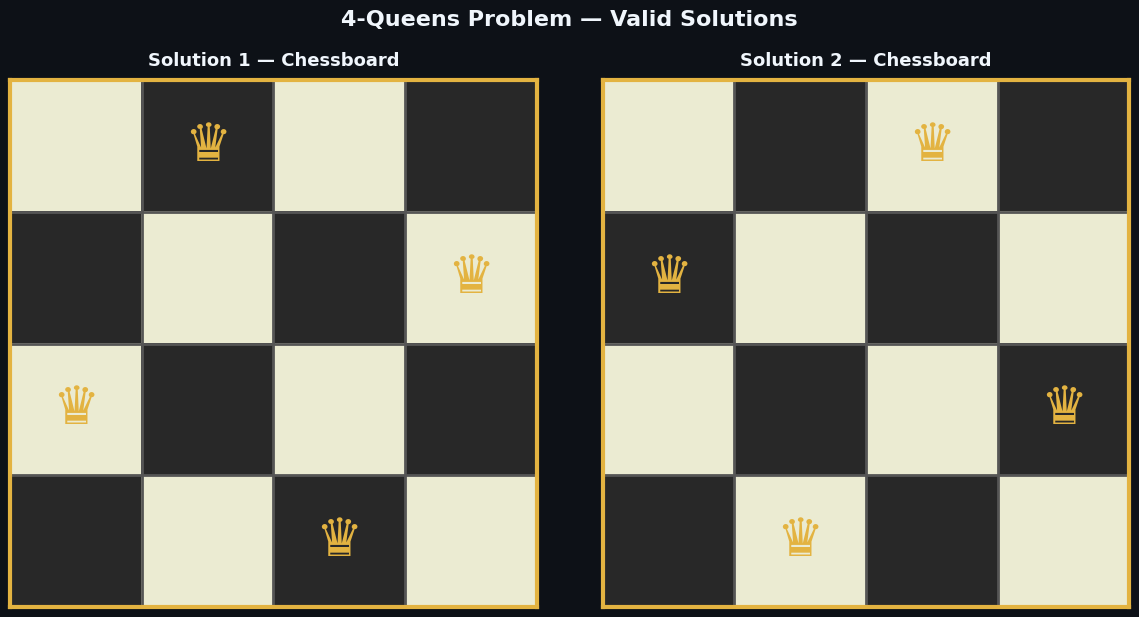

In [4]:
# ═══════════════════════════════════════════════════════════
#  CHESSBOARDS  —  both solutions side by side
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(all_solutions),
                          figsize=(6*len(all_solutions), 6),
                          facecolor=BG)
if len(all_solutions) == 1:
    axes = [axes]

for si, (ax, sol) in enumerate(zip(axes, all_solutions)):
    board = np.zeros((N, N, 3), dtype=np.uint8)
    for r in range(N):
        for c in range(N):
            board[r, c] = [235,235,210] if (r+c)%2==0 else [40,40,40]
    ax.imshow(board, interpolation='nearest')

    # Queens
    for r in range(N):
        for c in range(N):
            if sol[r][c] == 1:
                ax.text(c, r, '♛', ha='center', va='center',
                         fontsize=38, color=C['yellow'],
                         fontweight='bold',
                         path_effects=[])

    # Grid lines
    ax.set_xticks(np.arange(-.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-.5, N, 1), minor=True)
    ax.grid(which='minor', color='#555', linewidth=2)
    ax.tick_params(which='both', bottom=False, left=False,
                    labelbottom=False, labelleft=False)

    # Axis labels
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels([f'Col {c}' for c in range(N)],
                        color=C['white'], fontsize=9)
    ax.set_yticklabels([f'Row {r}' for r in range(N)],
                        color=C['white'], fontsize=9)
    ax.set_title(f'Solution {si+1} — Chessboard',
                  color=C['white'], fontsize=13, fontweight='bold', pad=10)
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_edgecolor(C['yellow'])
        sp.set_linewidth(3)

plt.suptitle('4-Queens Problem — Valid Solutions', color=C['white'],
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4 · Binary Matrix Heatmaps

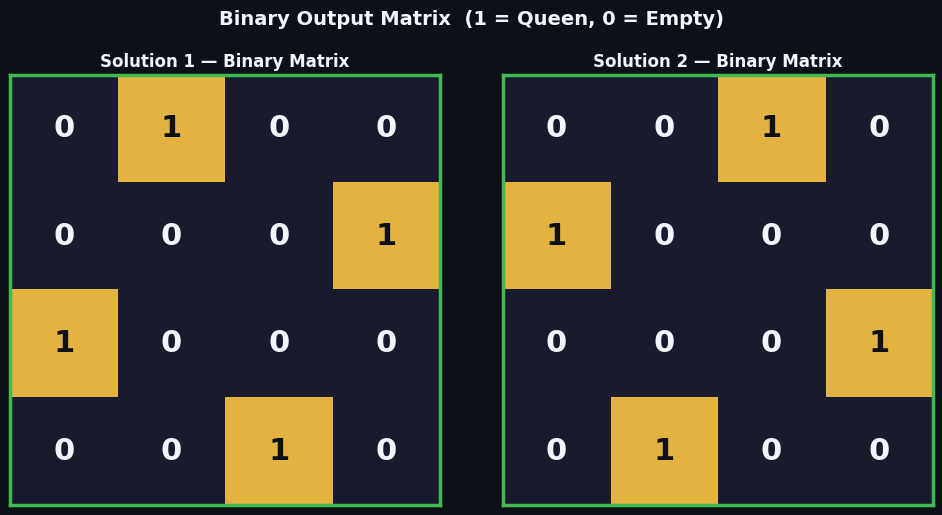

In [5]:
# ═══════════════════════════════════════════════════════════
#  HEATMAP  —  binary (0/1) matrix for each solution
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(all_solutions),
                          figsize=(5*len(all_solutions), 5),
                          facecolor=BG)
if len(all_solutions) == 1:
    axes = [axes]

cmap_bw = ListedColormap(['#1a1a2e', C['yellow']])

for si, (ax, sol) in enumerate(zip(axes, all_solutions)):
    mat = np.array(sol)
    ax.imshow(mat, cmap=cmap_bw, aspect='equal', interpolation='nearest')

    for r in range(N):
        for c in range(N):
            ax.text(c, r, str(mat[r, c]),
                     ha='center', va='center', fontsize=22,
                     fontweight='bold',
                     color=BG if mat[r, c]==1 else C['white'])

    ax.set_xticks(np.arange(-.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-.5, N, 1), minor=True)
    ax.grid(which='minor', color='#555', linewidth=2)
    ax.tick_params(which='both', bottom=False, left=False,
                    labelbottom=False, labelleft=False)
    ax.set_title(f'Solution {si+1} — Binary Matrix',
                  color=C['white'], fontsize=12, fontweight='bold')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(C['green']); sp.set_linewidth(2.5)

plt.suptitle('Binary Output Matrix  (1 = Queen, 0 = Empty)',
              color=C['white'], fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5 · Attack / Threat Map (Heatmap)

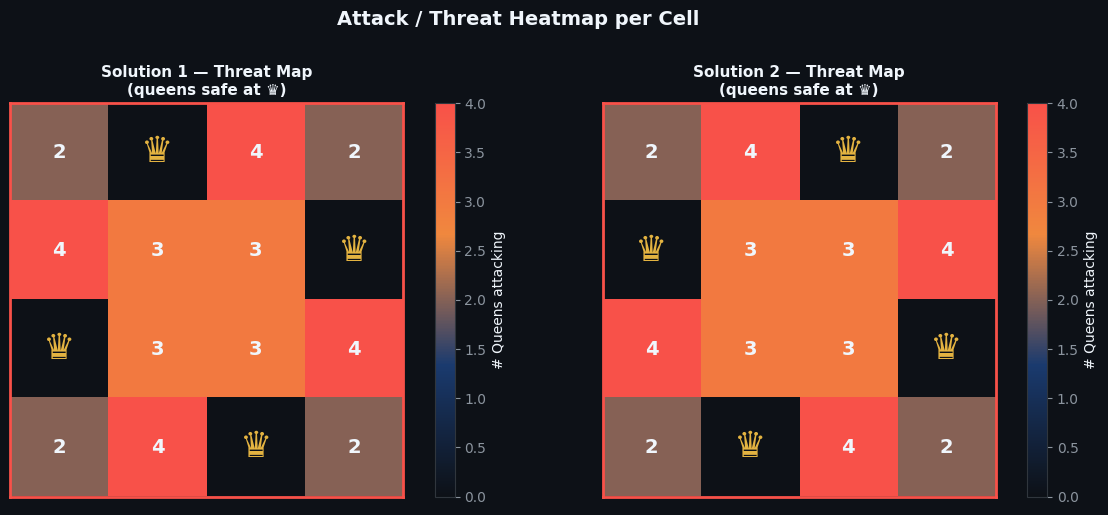

In [6]:
# ═══════════════════════════════════════════════════════════
#  THREAT HEATMAP  —  how many queens attack each cell
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(all_solutions),
                          figsize=(6*len(all_solutions), 5),
                          facecolor=BG)
if len(all_solutions) == 1:
    axes = [axes]

cmap_threat = LinearSegmentedColormap.from_list('threat',
              ['#0d1117', '#1a3a6e', C['orange'], C['red']])

for si, (ax, sol) in enumerate(zip(axes, all_solutions)):
    threat = np.zeros((N, N))
    for r in range(N):
        qc = sol[r].index(1)
        for c in range(N):
            if c == qc: continue
            threat[r, c] += 1                       # same row
        for rr in range(N):
            if rr == r: continue
            threat[rr, qc] += 1                     # same column
        for dr, dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
            nr, nc = r+dr, qc+dc
            while 0 <= nr < N and 0 <= nc < N:
                threat[nr, nc] += 1
                nr += dr; nc += dc

    # normalize for display
    im = ax.imshow(threat, cmap=cmap_threat, aspect='equal',
                    interpolation='nearest', vmin=0)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.06,
                  label='# Queens attacking')

    for r in range(N):
        for c in range(N):
            if sol[r][c] == 1:
                ax.text(c, r, '♛', ha='center', va='center',
                         fontsize=26, color=C['yellow'], fontweight='bold')
            else:
                ax.text(c, r, str(int(threat[r, c])),
                         ha='center', va='center',
                         fontsize=14, color=C['white'], fontweight='bold')

    ax.set_xticks(np.arange(-.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-.5, N, 1), minor=True)
    ax.grid(which='minor', color='#444', linewidth=1.5)
    ax.tick_params(which='both', bottom=False, left=False,
                    labelbottom=False, labelleft=False)
    ax.set_title(f'Solution {si+1} — Threat Map\n(queens safe at ♛)',
                  color=C['white'], fontsize=11, fontweight='bold')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(C['red']); sp.set_linewidth(2)

plt.suptitle('Attack / Threat Heatmap per Cell',
              color=C['white'], fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6 · Queen Positions — Scatter Plot

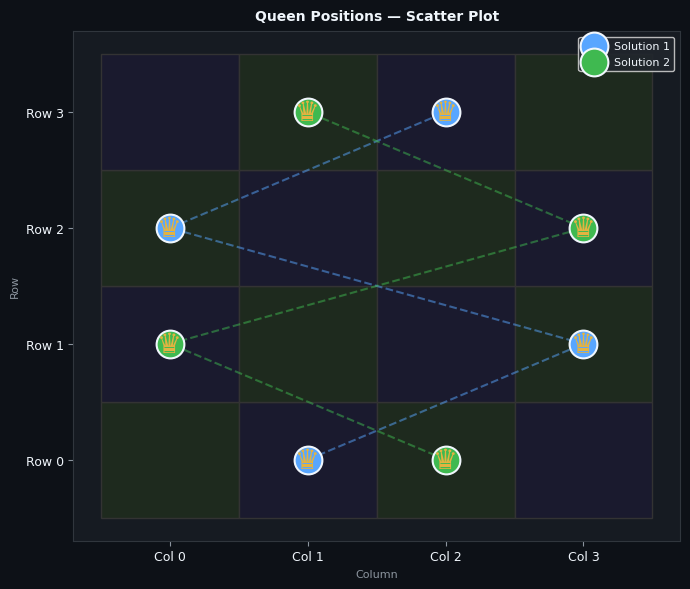

In [7]:
# ═══════════════════════════════════════════════════════════
#  SCATTER PLOT  —  queen positions on grid
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style(ax, 'Queen Positions Scatter', 'Column', 'Row')

# Draw grid cells as background squares
for r in range(N):
    for c in range(N):
        fc = '#1e2a1e' if (r+c)%2==0 else '#1a1a2e'
        ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1,
                                    facecolor=fc, edgecolor='#333',
                                    linewidth=1, zorder=0))

# Plot queens for each solution
for si, sol in enumerate(all_solutions):
    xs = [sol[r].index(1) for r in range(N)]
    ys = list(range(N))
    ax.scatter(xs, ys, s=400, color=PAL[si], zorder=4,
                label=f'Solution {si+1}',
                edgecolors=C['white'], linewidths=1.5)
    ax.plot(xs, ys, '--', color=PAL[si], alpha=0.5,
             linewidth=1.5, zorder=3)
    for x, y in zip(xs, ys):
        ax.text(x, y, '♛', ha='center', va='center',
                 fontsize=20, color=C['yellow'], zorder=5)

ax.set_xlim(-0.7, N-0.3); ax.set_ylim(-0.7, N-0.3)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels([f'Col {c}' for c in range(N)],
                    color=C['white'], fontsize=9)
ax.set_yticklabels([f'Row {r}' for r in range(N)],
                    color=C['white'], fontsize=9)
style(ax, 'Queen Positions — Scatter Plot', 'Column', 'Row',
       grid=False, legend=True)
plt.tight_layout()
plt.show()


## 7 · Queen Column per Row — Bar Charts

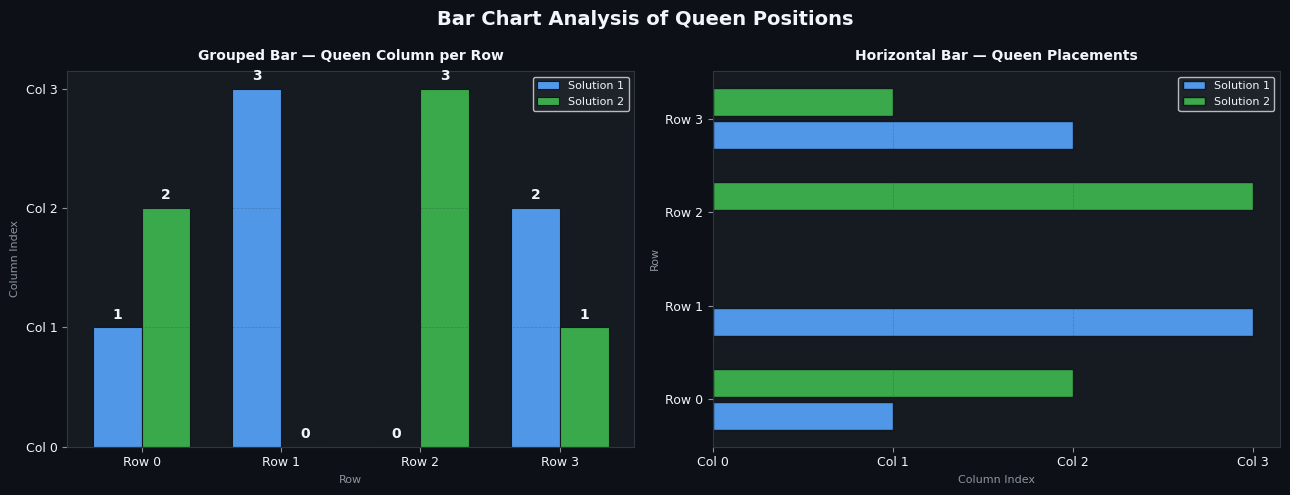

In [8]:
# ═══════════════════════════════════════════════════════════
#  BAR CHARTS  —  grouped + horizontal
# ═══════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# ── Grouped vertical bar ───────────────────────────────────
width = 0.35
x = np.arange(N)
for si, sol in enumerate(all_solutions):
    cols_ = [sol[r].index(1) for r in range(N)]
    bars = ax1.bar(x + si*width, cols_, width,
                    label=f'Solution {si+1}',
                    color=PAL[si], edgecolor=BG,
                    linewidth=0.8, alpha=0.9)
    for bar, v in zip(bars, cols_):
        ax1.text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.05, str(v),
                  ha='center', va='bottom',
                  color=C['white'], fontsize=10, fontweight='bold')

ax1.set_xticks(x + width/2)
ax1.set_xticklabels([f'Row {r}' for r in range(N)],
                     color=C['white'], fontsize=9)
ax1.set_yticks(range(N))
ax1.set_yticklabels([f'Col {c}' for c in range(N)],
                     color=C['white'], fontsize=9)
style(ax1, 'Grouped Bar — Queen Column per Row',
       'Row', 'Column Index', grid=True, legend=True)

# ── Horizontal bar ─────────────────────────────────────────
for si, sol in enumerate(all_solutions):
    cols_ = [sol[r].index(1) for r in range(N)]
    y = np.arange(N) + si*0.35
    ax2.barh(y, cols_, 0.3,
              label=f'Solution {si+1}',
              color=PAL[si], edgecolor=BG, alpha=0.9)
ax2.set_yticks(np.arange(N)+0.175)
ax2.set_yticklabels([f'Row {r}' for r in range(N)],
                     color=C['white'], fontsize=9)
ax2.set_xticks(range(N))
ax2.set_xticklabels([f'Col {c}' for c in range(N)],
                     color=C['white'], fontsize=9)
style(ax2, 'Horizontal Bar — Queen Placements',
       'Column Index', 'Row', grid=True, legend=True)

plt.suptitle('Bar Chart Analysis of Queen Positions',
              color=C['white'], fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8 · Binary Row Composition — Stacked Bar

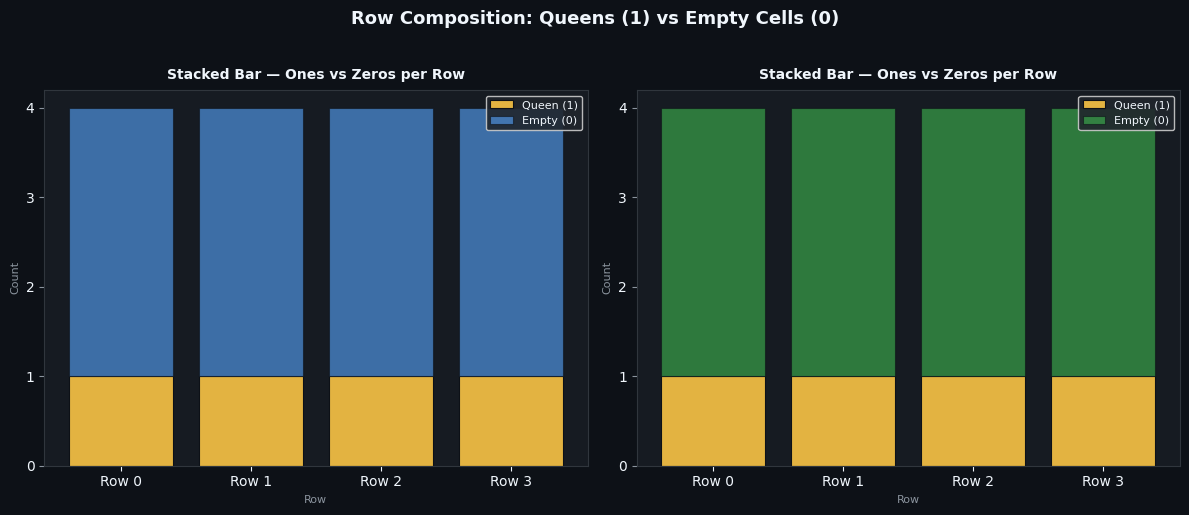

In [9]:
# ═══════════════════════════════════════════════════════════
#  STACKED BAR  —  ones vs zeros per row for each solution
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(all_solutions),
                          figsize=(6*len(all_solutions), 5),
                          facecolor=BG)
if len(all_solutions) == 1:
    axes = [axes]

for si, (ax, sol) in enumerate(zip(axes, all_solutions)):
    rows   = [f'Row {r}' for r in range(N)]
    queens = [row.count(1) for row in sol]
    empties= [row.count(0) for row in sol]

    ax.bar(rows, queens,  color=C['yellow'], edgecolor=BG,
            label='Queen (1)', linewidth=0.8)
    ax.bar(rows, empties, bottom=queens, color=PAL[si],
            edgecolor=BG, alpha=0.6, label='Empty (0)', linewidth=0.8)

    ax.set_yticks([0, 1, 2, 3, 4])
    ax.set_yticklabels(['0','1','2','3','4'], color=C['white'])
    ax.tick_params(axis='x', colors=C['white'])
    style(ax, 'Stacked Bar — Ones vs Zeros per Row',
           'Row', 'Count', legend=True)

plt.suptitle('Row Composition: Queens (1) vs Empty Cells (0)',
              color=C['white'], fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 9 · Pie & Donut Charts

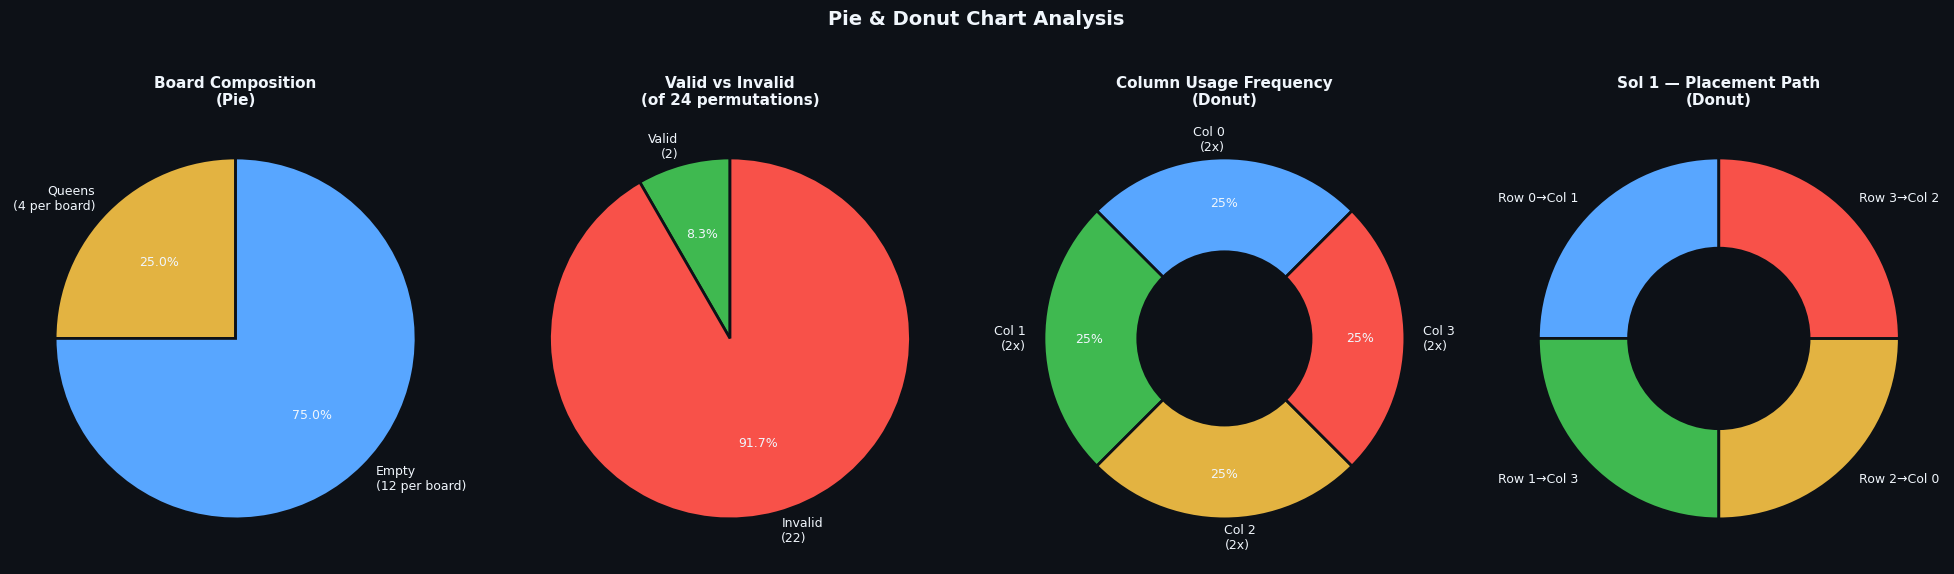

In [10]:
# ═══════════════════════════════════════════════════════════
#  PIE + DONUT  —  multiple angles on the solutions
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(20, 6), facecolor=BG)
for ax in axes: ax.set_facecolor(PANEL)

# 1. Pie — board cells: queens vs empty
total_cells   = N * N
total_queens  = N * len(all_solutions)
total_empty   = total_cells * len(all_solutions) - total_queens
axes[0].pie(
    [total_queens, total_empty],
    labels=[f'Queens\n({N} per board)', f'Empty\n({N*N-N} per board)'],
    colors=[C['yellow'], C['blue']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor=BG, linewidth=2),
    textprops=dict(color=C['white'], fontsize=9)
)
axes[0].set_title('Board Composition\n(Pie)', color=C['white'],
                    fontsize=11, fontweight='bold')

# 2. Pie — solutions found vs not found (out of all 4! permutations)
import math
all_perms = math.factorial(N)
axes[1].pie(
    [len(all_solutions), all_perms - len(all_solutions)],
    labels=[f'Valid\n({len(all_solutions)})', f'Invalid\n({all_perms-len(all_solutions)})'],
    colors=[C['green'], C['red']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor=BG, linewidth=2),
    textprops=dict(color=C['white'], fontsize=9)
)
axes[1].set_title(f'Valid vs Invalid\n(of {all_perms} permutations)',
                    color=C['white'], fontsize=11, fontweight='bold')

# 3. Donut — column usage frequency across all solutions
col_freq = [0]*N
for sol in all_solutions:
    for r in range(N): col_freq[sol[r].index(1)] += 1
axes[2].pie(
    col_freq,
    labels=[f'Col {c}\n({col_freq[c]}x)' for c in range(N)],
    colors=PAL[:N],
    autopct='%1.0f%%', startangle=45, pctdistance=0.75,
    wedgeprops=dict(width=0.52, edgecolor=BG, linewidth=2),
    textprops=dict(color=C['white'], fontsize=9)
)
axes[2].set_title('Column Usage Frequency\n(Donut)', color=C['white'],
                    fontsize=11, fontweight='bold')

# 4. Donut — row-by-row queen placement (solution 1)
sol0_cols = [all_solutions[0][r].index(1) for r in range(N)]
axes[3].pie(
    [1]*N,
    labels=[f'Row {r}→Col {sol0_cols[r]}' for r in range(N)],
    colors=PAL[:N],
    autopct='', startangle=90, pctdistance=0.6,
    wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=2),
    textprops=dict(color=C['white'], fontsize=9)
)
axes[3].set_title('Sol 1 — Placement Path\n(Donut)', color=C['white'],
                    fontsize=11, fontweight='bold')

plt.suptitle('Pie & Donut Chart Analysis',
              color=C['white'], fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 10 · DFS Backtrack Depth — Step & Area Plot

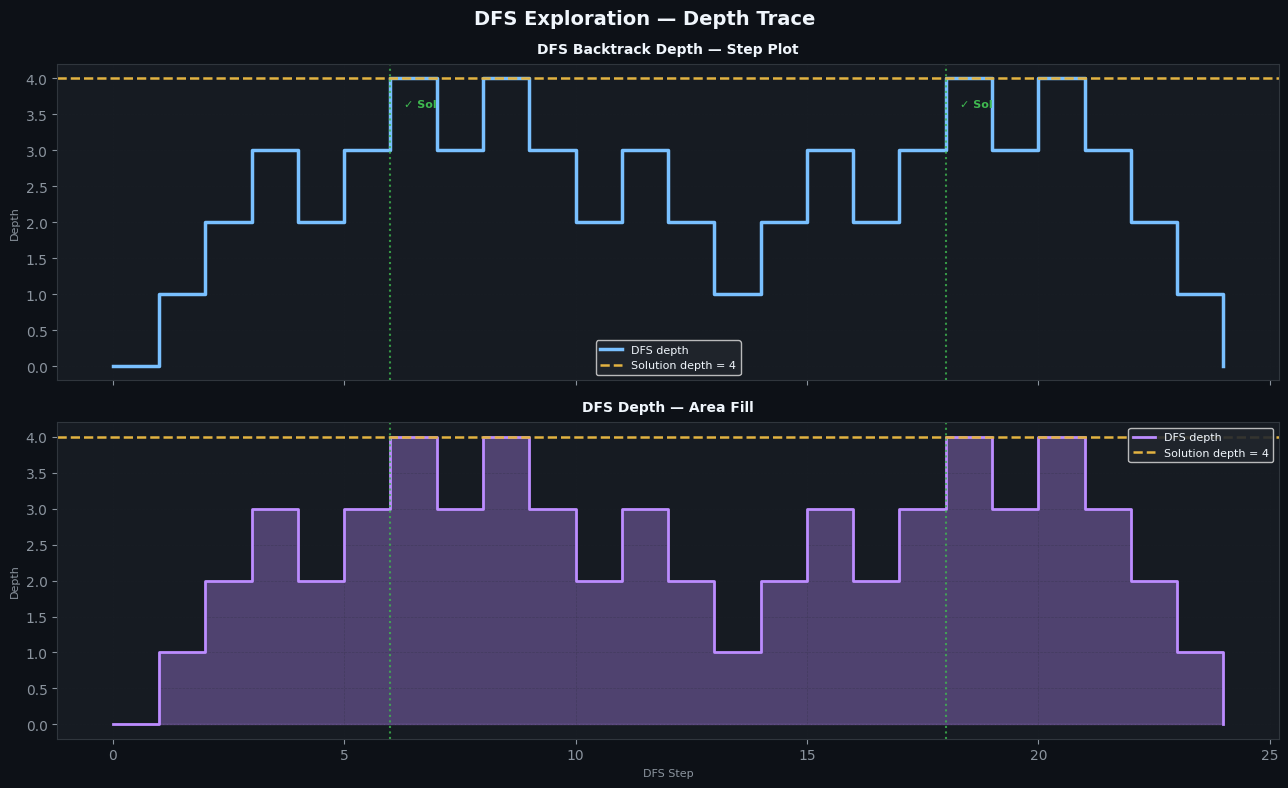

In [11]:
# ═══════════════════════════════════════════════════════════
#  STEP + AREA  —  simulated DFS depth trace
# ═══════════════════════════════════════════════════════════
# Simulated DFS call-stack depths as the algorithm explores
dfs_trace  = [0,1,2,3,2,3,4,3,4,3,2,3,2,1,2,3,2,3,4,3,4,3,2,1,0]
dfs_steps  = list(range(len(dfs_trace)))
solution_steps = [6, 18]   # steps where solutions were found

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
                                 sharex=True, facecolor=BG)

# Step plot
ax1.step(dfs_steps, dfs_trace, color=C['cyan'], linewidth=2.5,
          where='post', label='DFS depth')
ax1.axhline(N, color=C['yellow'], linestyle='--',
             linewidth=1.8, label=f'Solution depth = {N}')
for ss in solution_steps:
    ax1.axvline(ss, color=C['green'], linestyle=':', linewidth=1.5,
                 alpha=0.8)
    ax1.text(ss+0.3, 3.6, '✓ Sol', color=C['green'],
              fontsize=8, fontweight='bold')
style(ax1, 'DFS Backtrack Depth — Step Plot',
       '', 'Depth', grid=True, legend=True)

# Area fill
ax2.fill_between(dfs_steps, dfs_trace, step='post',
                  alpha=0.35, color=C['purple'])
ax2.step(dfs_steps, dfs_trace, color=C['purple'], linewidth=2,
          where='post', label='DFS depth')
ax2.axhline(N, color=C['yellow'], linestyle='--', linewidth=1.8,
             label=f'Solution depth = {N}')
for ss in solution_steps:
    ax2.axvline(ss, color=C['green'], linestyle=':', linewidth=1.5, alpha=0.8)
style(ax2, 'DFS Depth — Area Fill',
       'DFS Step', 'Depth', grid=True, legend=True)

plt.suptitle('DFS Exploration — Depth Trace',
              color=C['white'], fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11 · Queen Column Path — Line Plot

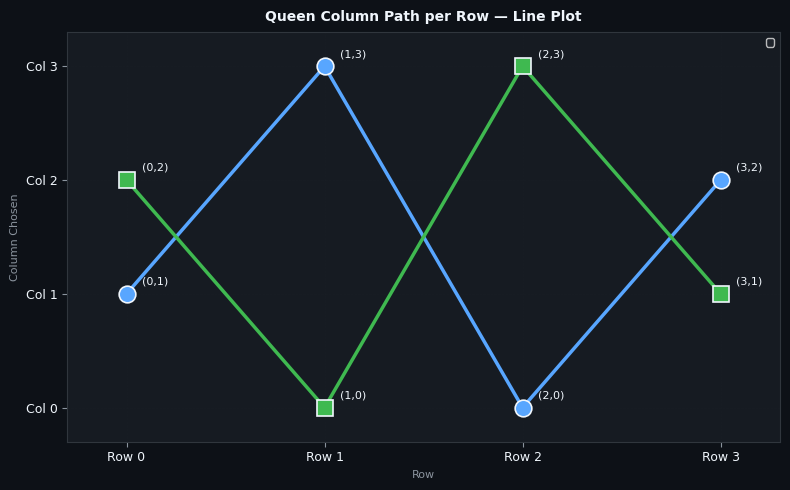

In [12]:
# ═══════════════════════════════════════════════════════════
#  LINE PLOT  —  column chosen at each row for each solution
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style(ax, 'Queen Column Path per Row — Line Plot',
       'Row', 'Column Chosen', grid=True, legend=True)

markers = ['o', 's']
for si, sol in enumerate(all_solutions):
    xs = list(range(N))
    ys = [sol[r].index(1) for r in range(N)]
    ax.plot(xs, ys, marker=markers[si], color=PAL[si],
             linewidth=2.5, markersize=12,
             markeredgecolor=C['white'], markeredgewidth=1.2,
             label=f'Solution {si+1}', zorder=3)
    for x, y in zip(xs, ys):
        ax.text(x+0.08, y+0.08, f'({x},{y})',
                 color=C['white'], fontsize=8)

ax.set_xticks(range(N))
ax.set_xticklabels([f'Row {r}' for r in range(N)],
                    color=C['white'], fontsize=9)
ax.set_yticks(range(N))
ax.set_yticklabels([f'Col {c}' for c in range(N)],
                    color=C['white'], fontsize=9)
ax.set_xlim(-0.3, N-0.7); ax.set_ylim(-0.3, N-0.7)
plt.tight_layout()
plt.show()


## 12 · Column Frequency — Histogram

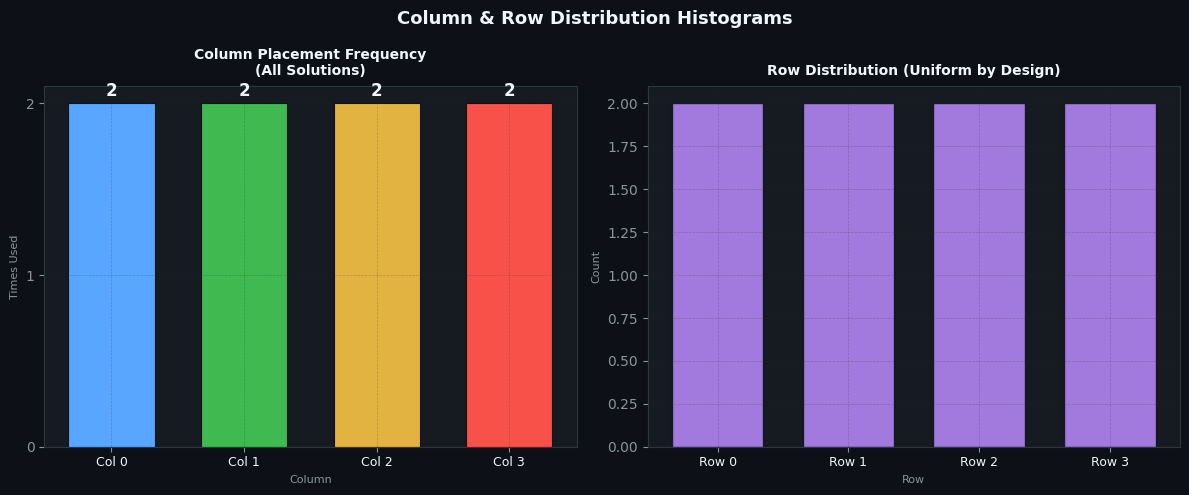

In [13]:
# ═══════════════════════════════════════════════════════════
#  HISTOGRAM  —  how often each column is used
# ═══════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)

# Histogram across all solutions
all_col_placements = []
for sol in all_solutions:
    for r in range(N): all_col_placements.append(sol[r].index(1))

counts = [all_col_placements.count(c) for c in range(N)]
bars = ax1.bar(range(N), counts,
                color=PAL[:N], edgecolor=BG, width=0.65,
                linewidth=0.8)
for bar, v in zip(bars, counts):
    ax1.text(bar.get_x()+bar.get_width()/2,
              bar.get_height()+0.02, str(v),
              ha='center', va='bottom',
              color=C['white'], fontsize=12, fontweight='bold')
ax1.set_xticks(range(N))
ax1.set_xticklabels([f'Col {c}' for c in range(N)],
                     color=C['white'], fontsize=9)
ax1.set_yticks([0, 1, 2])
style(ax1, 'Column Placement Frequency\n(All Solutions)',
       'Column', 'Times Used', grid=True)

# Histogram — row index distribution (should be uniform)
row_dist = list(range(N)) * len(all_solutions)
ax2.hist(row_dist, bins=N, range=(-0.5, N-0.5),
          color=C['purple'], edgecolor=BG,
          rwidth=0.7, alpha=0.85)
ax2.set_xticks(range(N))
ax2.set_xticklabels([f'Row {r}' for r in range(N)],
                     color=C['white'], fontsize=9)
style(ax2, 'Row Distribution (Uniform by Design)',
       'Row', 'Count', grid=True)

plt.suptitle('Column & Row Distribution Histograms',
              color=C['white'], fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 13 · Column Spread — Box Plot

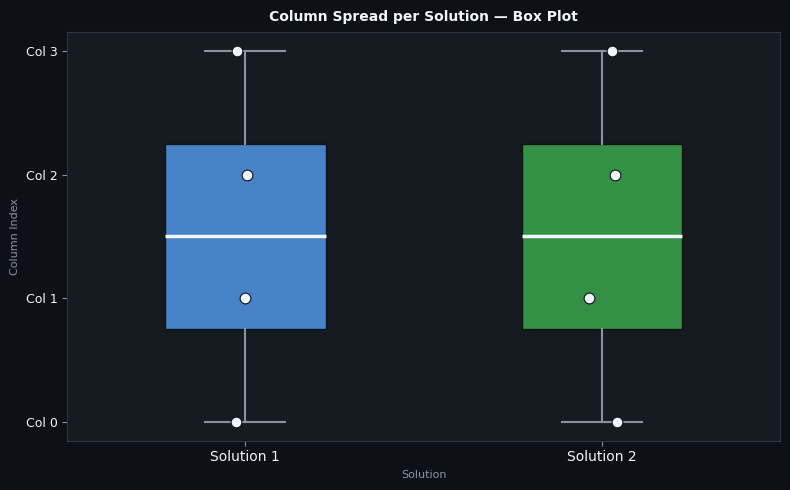

In [14]:
# ═══════════════════════════════════════════════════════════
#  BOX PLOT  —  column spread per solution
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)

data_box = [[sol[r].index(1) for r in range(N)]
             for sol in all_solutions]
labels   = [f'Solution {i+1}' for i in range(len(all_solutions))]

bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                 widths=0.45,
                 medianprops=dict(color=C['white'], linewidth=2.5),
                 whiskerprops=dict(color=C['gray'], linewidth=1.5),
                 capprops=dict(color=C['gray'], linewidth=1.5),
                 flierprops=dict(marker='D',
                                  markerfacecolor=C['yellow'],
                                  markersize=8))
for patch, col in zip(bp['boxes'], PAL):
    patch.set_facecolor(col); patch.set_alpha(0.75)

# Overlay individual points
for i, data in enumerate(data_box):
    y = data
    x = [i+1 + np.random.uniform(-0.05, 0.05) for _ in y]
    ax.scatter(x, y, color=C['white'], s=60, zorder=4,
                edgecolors=BG, linewidths=0.8)

ax.set_xticklabels(labels, color=C['white'], fontsize=10)
ax.set_yticks(range(N))
ax.set_yticklabels([f'Col {c}' for c in range(N)],
                    color=C['white'], fontsize=9)
style(ax, 'Column Spread per Solution — Box Plot',
       'Solution', 'Column Index', grid=True)
plt.tight_layout()
plt.show()


## 14 · Queen Column Values — Radar / Spider Chart

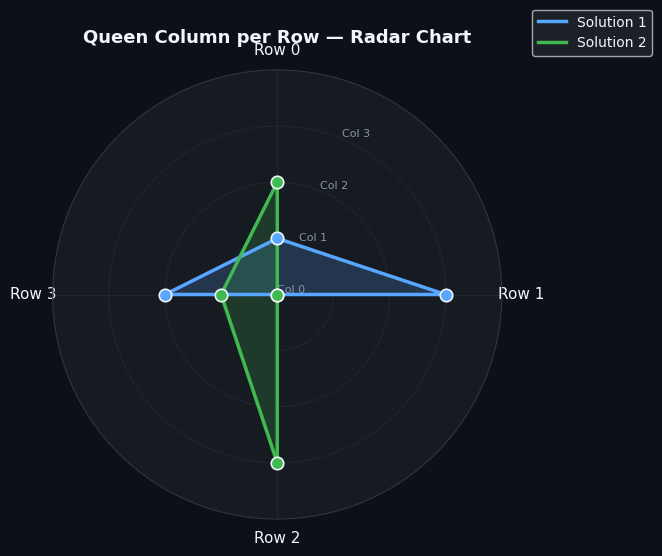

In [15]:
# ═══════════════════════════════════════════════════════════
#  RADAR / SPIDER CHART  —  column per row for each solution
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG,
                        subplot_kw=dict(projection='polar'))
ax.set_facecolor(PANEL)

categories = [f'Row {r}' for r in range(N)]
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories,
                   color=C['white'], fontsize=11)
ax.set_ylim(0, N)
ax.set_yticks(range(N))
ax.set_yticklabels([f'Col {c}' for c in range(N)],
                    color=C['gray'], fontsize=8)
ax.grid(color=LINE, alpha=0.6)

for si, sol in enumerate(all_solutions):
    vals = [sol[r].index(1) for r in range(N)]
    vals += vals[:1]   # close
    ax.plot(angles, vals, color=PAL[si], linewidth=2.5,
             label=f'Solution {si+1}')
    ax.fill(angles, vals, color=PAL[si], alpha=0.20)
    # Mark each queen
    for ang, val in zip(angles[:-1], vals[:-1]):
        ax.scatter(ang, val, color=PAL[si], s=80, zorder=5,
                    edgecolors=C['white'], linewidths=1.2)

ax.set_title('Queen Column per Row — Radar Chart',
              color=C['white'], fontsize=13,
              fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
           facecolor=CARD, labelcolor=C['white'], fontsize=10)
plt.tight_layout()
plt.show()


## 15 · DFS Search Tree Visualisation

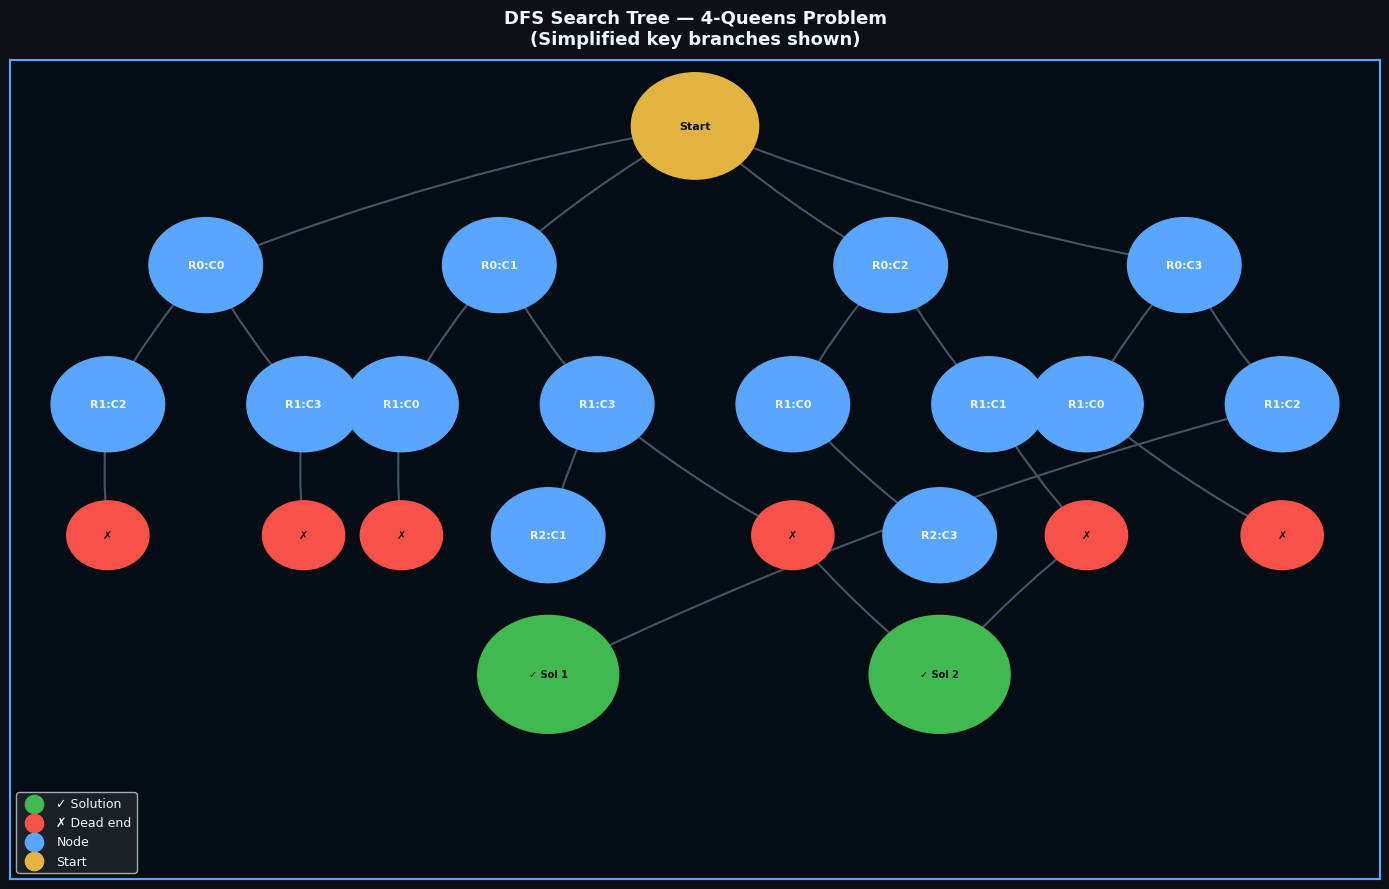

In [16]:
# ═══════════════════════════════════════════════════════════
#  DFS TREE  —  annotated search tree sketch
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 9), facecolor=BG)
ax.set_facecolor('#050d14')
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_edgecolor(C['blue']); sp.set_linewidth(1.5)

# Tree node positions
nodes = [
    (7,   9.2, 'Start'),
    # Row 0 choices
    (2,   7.5, 'R0:C0'), (5,   7.5, 'R0:C1'),
    (9,   7.5, 'R0:C2'), (12,  7.5, 'R0:C3'),
    # Row 1 choices (only key branches)
    (1,   5.8, 'R1:C2'), (3,   5.8, 'R1:C3'),
    (4,   5.8, 'R1:C0'), (6,   5.8, 'R1:C3'),
    (8,   5.8, 'R1:C0'), (10,  5.8, 'R1:C1'),
    (11,  5.8, 'R1:C0'), (13,  5.8, 'R1:C2'),
    # Row 2 (key leaves)
    (1,   4.2, '✗'),   (3,   4.2, '✗'),
    (4,   4.2, '✗'),   (5.5, 4.2, 'R2:C1'),
    (8,   4.2, '✗'),   (9.5, 4.2, 'R2:C3'),
    (11,  4.2, '✗'),   (13,  4.2, '✗'),
    # Solutions
    (5.5, 2.5, '✓ Sol 1'), (9.5, 2.5, '✓ Sol 2'),
]
edges = [
    (0,1),(0,2),(0,3),(0,4),
    (1,5),(1,6),(2,7),(2,8),(3,9),(3,10),(4,11),(4,12),
    (5,13),(6,14),(7,15),(8,16),(8,17),(9,18),(10,19),(11,20),(12,21),
    (17,22),(19,22),
]

xy = {i:(x,y) for i,(x,y,_) in enumerate(nodes)}
for s,e in edges:
    x0,y0=xy[s]; x1,y1=xy[e]
    ax.annotate('', xy=(x1,y1), xytext=(x0,y0),
                 arrowprops=dict(arrowstyle='->', color='#445566',
                                  lw=1.5, connectionstyle='arc3,rad=0.05'))

for i,(x,y,lbl) in enumerate(nodes):
    if '✓' in lbl:
        col=C['green']; sz=0.72; fc=C['green']; tc=BG
    elif lbl=='✗':
        col=C['red']; sz=0.42; fc=C['red']; tc=BG
    elif lbl=='Start':
        col=C['yellow']; sz=0.65; fc=C['yellow']; tc=BG
    else:
        col=C['blue']; sz=0.58; fc=C['blue']; tc=C['white']
    circle=plt.Circle((x,y), sz, color=fc, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, lbl, ha='center', va='center',
             fontsize=7 if len(lbl)>5 else 8,
             color=tc, fontweight='bold', zorder=4)

# Legend
for label,col in [('✓ Solution',C['green']),
                   ('✗ Dead end', C['red']),
                   ('Node',      C['blue']),
                   ('Start',     C['yellow'])]:
    ax.scatter([],[], s=120, c=col, label=label)
ax.legend(loc='lower left', facecolor=CARD,
           labelcolor=C['white'], fontsize=9, markerscale=1.2)

ax.set_title('DFS Search Tree — 4-Queens Problem\n'
              '(Simplified key branches shown)',
              color=C['white'], fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 16 · Summary Statistics — Pandas DataFrame

In [17]:
# ═══════════════════════════════════════════════════════════
#  PANDAS  —  full summary statistics
# ═══════════════════════════════════════════════════════════
import math

rows_data = []
for si, sol in enumerate(all_solutions):
    col_positions = [sol[r].index(1) for r in range(N)]
    rows_data.append({
        'Solution'      : f'Sol {si+1}',
        'Queen Cols'    : str(col_positions),
        'Col Mean'      : round(np.mean(col_positions), 2),
        'Col Std'       : round(np.std(col_positions),  2),
        'Col Min'       : min(col_positions),
        'Col Max'       : max(col_positions),
        'Unique Cols'   : len(set(col_positions)),
        'Binary Rows'   : str([''.join(map(str,r)) for r in sol]),
    })

df_summary = pd.DataFrame(rows_data)
print("=" * 60)
print("  4-QUEENS  —  COMPLETE SOLUTION SUMMARY")
print("=" * 60)
print(df_summary.to_string(index=False))
print()
print(f"  Board size          : {N} × {N}")
print(f"  Total permutations  : {math.factorial(N)} (4!)")
print(f"  Valid solutions     : {len(all_solutions)}")
print(f"  Success rate        : {len(all_solutions)/math.factorial(N)*100:.1f}%")


  4-QUEENS  —  COMPLETE SOLUTION SUMMARY
Solution   Queen Cols  Col Mean  Col Std  Col Min  Col Max  Unique Cols                      Binary Rows
   Sol 1 [1, 3, 0, 2]       1.5     1.12        0        3            4 ['0100', '0001', '1000', '0010']
   Sol 2 [2, 0, 3, 1]       1.5     1.12        0        3            4 ['0010', '1000', '0001', '0100']

  Board size          : 4 × 4
  Total permutations  : 24 (4!)
  Valid solutions     : 2
  Success rate        : 8.3%


## 17 · Master Summary Figure (All Charts Combined)

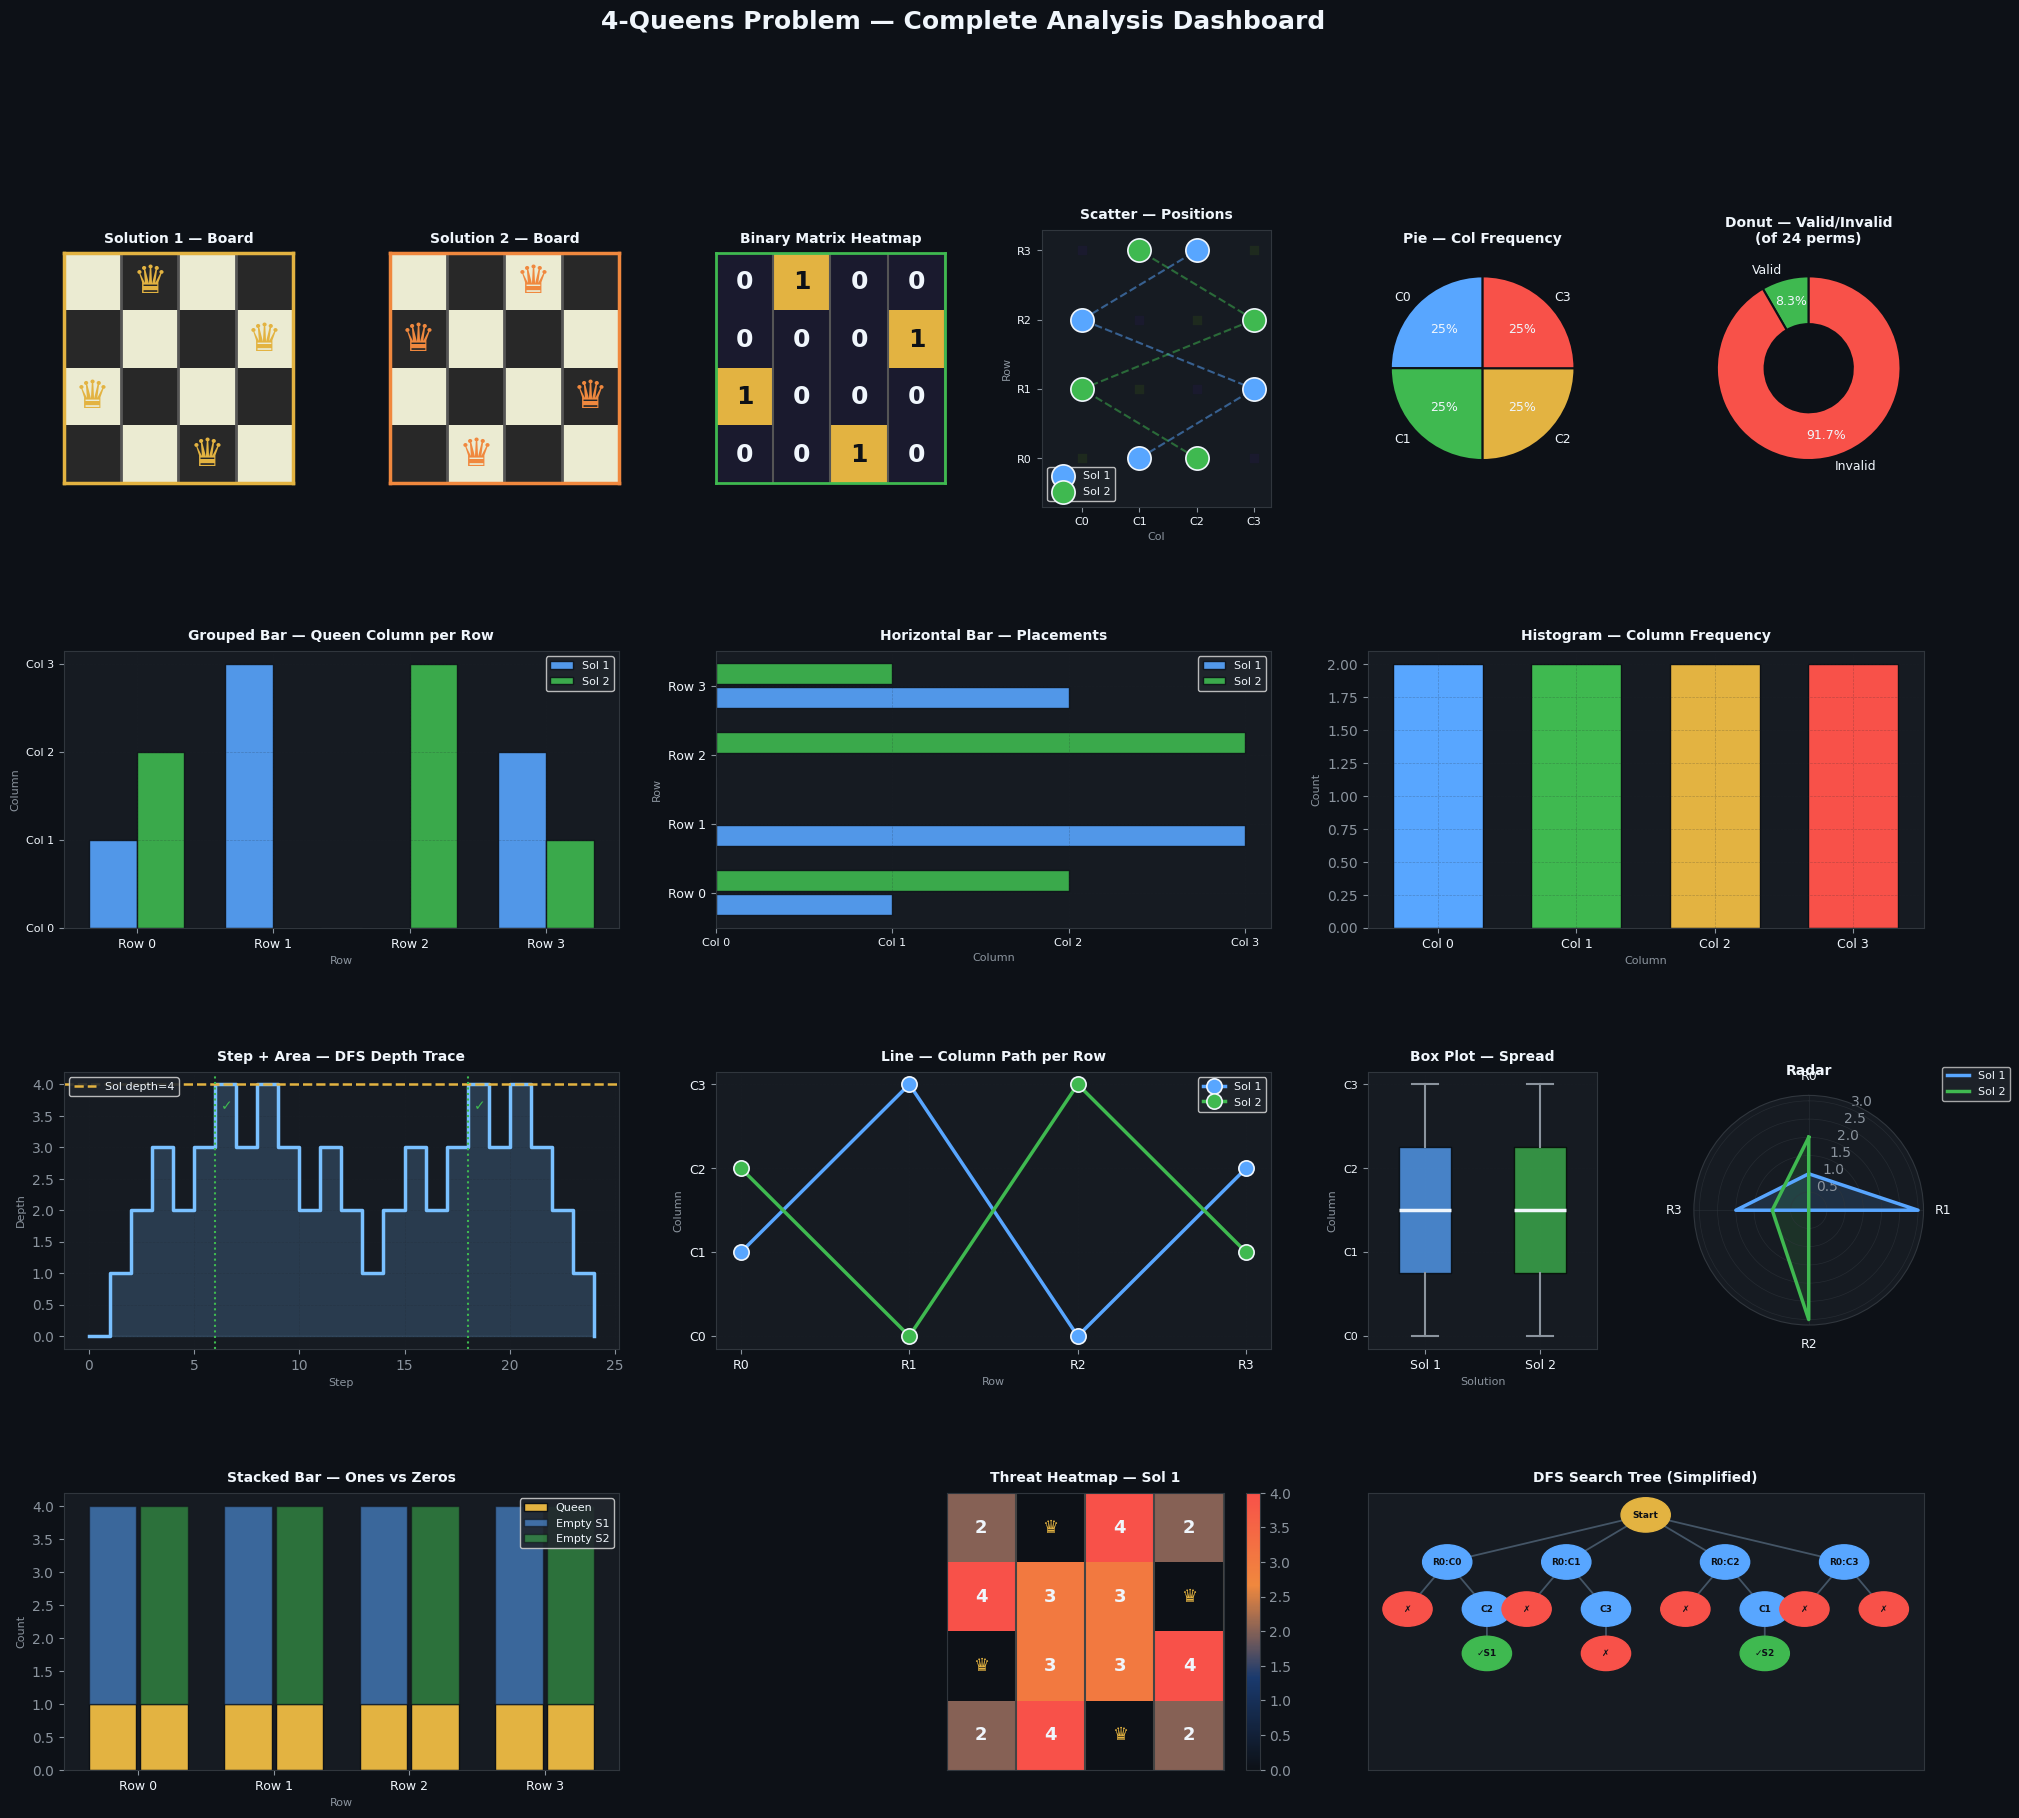


✓ Master dashboard complete


In [18]:
# ═══════════════════════════════════════════════════════════
#  MASTER FIGURE  —  all chart types on one sheet
# ═══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(24, 20), facecolor=BG)
fig.suptitle('4-Queens Problem — Complete Analysis Dashboard',
              color=C['white'], fontsize=18, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.52, wspace=0.42)

# ── Chessboard sol 1 ──────────────────────────────────────
ax_c1 = fig.add_subplot(gs[0, 0])
sol = all_solutions[0]
board_img = np.zeros((N,N,3),dtype=np.uint8)
for r in range(N):
    for c in range(N):
        board_img[r,c] = [235,235,210] if (r+c)%2==0 else [40,40,40]
ax_c1.imshow(board_img, interpolation='nearest')
for r in range(N):
    for c in range(N):
        if sol[r][c]==1:
            ax_c1.text(c,r,'♛',ha='center',va='center',
                        fontsize=28,color=C['yellow'],fontweight='bold')
ax_c1.set_xticks(np.arange(-.5,N,1),minor=True)
ax_c1.set_yticks(np.arange(-.5,N,1),minor=True)
ax_c1.grid(which='minor',color='#555',linewidth=2)
ax_c1.tick_params(which='both',bottom=False,left=False,
                   labelbottom=False,labelleft=False)
style(ax_c1,'Solution 1 — Board')
for sp in ax_c1.spines.values():
    sp.set_visible(True); sp.set_edgecolor(C['yellow']); sp.set_linewidth(2.5)

# ── Chessboard sol 2 ──────────────────────────────────────
ax_c2 = fig.add_subplot(gs[0, 1])
sol2 = all_solutions[1]
board2 = np.zeros((N,N,3),dtype=np.uint8)
for r in range(N):
    for c in range(N):
        board2[r,c]=[235,235,210] if (r+c)%2==0 else [40,40,40]
ax_c2.imshow(board2, interpolation='nearest')
for r in range(N):
    for c in range(N):
        if sol2[r][c]==1:
            ax_c2.text(c,r,'♛',ha='center',va='center',
                        fontsize=28,color=C['orange'],fontweight='bold')
ax_c2.set_xticks(np.arange(-.5,N,1),minor=True)
ax_c2.set_yticks(np.arange(-.5,N,1),minor=True)
ax_c2.grid(which='minor',color='#555',linewidth=2)
ax_c2.tick_params(which='both',bottom=False,left=False,
                   labelbottom=False,labelleft=False)
style(ax_c2,'Solution 2 — Board')
for sp in ax_c2.spines.values():
    sp.set_visible(True); sp.set_edgecolor(C['orange']); sp.set_linewidth(2.5)

# ── Binary heatmap ────────────────────────────────────────
ax_h = fig.add_subplot(gs[0, 2])
mat = np.array(all_solutions[0])
ax_h.imshow(mat,cmap=ListedColormap(['#1a1a2e',C['yellow']]),
             aspect='equal',interpolation='nearest')
for r in range(N):
    for c in range(N):
        ax_h.text(c,r,str(mat[r,c]),ha='center',va='center',fontsize=18,
                   fontweight='bold',color=BG if mat[r,c]==1 else C['white'])
ax_h.set_xticks(np.arange(-.5,N,1),minor=True)
ax_h.set_yticks(np.arange(-.5,N,1),minor=True)
ax_h.grid(which='minor',color='#555',linewidth=1.5)
ax_h.tick_params(which='both',bottom=False,left=False,
                  labelbottom=False,labelleft=False)
style(ax_h,'Binary Matrix Heatmap')
for sp in ax_h.spines.values():
    sp.set_visible(True); sp.set_edgecolor(C['green']); sp.set_linewidth(2)

# ── Scatter ────────────────────────────────────────────────
ax_sc = fig.add_subplot(gs[0, 3])
for i in range(N):
    for j in range(N):
        ax_sc.scatter(j,i,s=35,color='#1e2a1e' if (i+j)%2==0 else '#1a1a2e',
                       marker='s',zorder=1)
for si,sol_i in enumerate(all_solutions):
    xs=[sol_i[r].index(1) for r in range(N)]; ys=list(range(N))
    ax_sc.scatter(xs,ys,s=280,color=PAL[si],label=f'Sol {si+1}',
                   edgecolors=C['white'],linewidths=1.2,zorder=3)
    ax_sc.plot(xs,ys,'--',color=PAL[si],alpha=0.5,linewidth=1.5,zorder=2)
ax_sc.set_xlim(-0.7,3.3); ax_sc.set_ylim(-0.7,3.3)
ax_sc.set_xticks(range(N)); ax_sc.set_yticks(range(N))
ax_sc.set_xticklabels([f'C{c}' for c in range(N)],color=C['white'],fontsize=8)
ax_sc.set_yticklabels([f'R{r}' for r in range(N)],color=C['white'],fontsize=8)
style(ax_sc,'Scatter — Positions','Col','Row',legend=True)

# ── Pie ─────────────────────────────────────────────────────
ax_pie = fig.add_subplot(gs[0, 4])
ax_pie.set_facecolor(PANEL)
col_freq2=[0]*N
for s in all_solutions:
    for r in range(N): col_freq2[s[r].index(1)]+=1
ax_pie.pie(col_freq2,labels=[f'C{i}' for i in range(N)],
            colors=PAL[:N],autopct='%1.0f%%',startangle=90,
            wedgeprops=dict(edgecolor=BG,linewidth=1.5),
            textprops=dict(color=C['white'],fontsize=9))
style(ax_pie,'Pie — Col Frequency')

# ── Donut ────────────────────────────────────────────────────
ax_don = fig.add_subplot(gs[0, 5])
ax_don.set_facecolor(PANEL)
import math as _m
ax_don.pie([len(all_solutions),_m.factorial(N)-len(all_solutions)],
            labels=['Valid','Invalid'],colors=[C['green'],C['red']],
            autopct='%1.1f%%',startangle=90,pctdistance=0.75,
            wedgeprops=dict(width=0.52,edgecolor=BG,linewidth=1.5),
            textprops=dict(color=C['white'],fontsize=9))
style(ax_don,f'Donut — Valid/Invalid\n(of {_m.factorial(N)} perms)')

# ── Grouped bar ──────────────────────────────────────────────
ax_gb = fig.add_subplot(gs[1, 0:2])
w=0.35; x=np.arange(N)
for si,sol_i in enumerate(all_solutions):
    cols_=[sol_i[r].index(1) for r in range(N)]
    ax_gb.bar(x+si*w,cols_,w,label=f'Sol {si+1}',
               color=PAL[si],edgecolor=BG,alpha=0.9)
ax_gb.set_xticks(x+w/2)
ax_gb.set_xticklabels([f'Row {r}' for r in range(N)],color=C['white'],fontsize=9)
ax_gb.set_yticks(range(N)); ax_gb.set_yticklabels([f'Col {c}' for c in range(N)],color=C['white'],fontsize=8)
style(ax_gb,'Grouped Bar — Queen Column per Row','Row','Column',grid=True,legend=True)

# ── Horizontal bar ────────────────────────────────────────────
ax_hb = fig.add_subplot(gs[1, 2:4])
for si,sol_i in enumerate(all_solutions):
    cols_=[sol_i[r].index(1) for r in range(N)]
    y=np.arange(N)+si*0.35
    ax_hb.barh(y,cols_,0.3,label=f'Sol {si+1}',color=PAL[si],edgecolor=BG,alpha=0.9)
ax_hb.set_yticks(np.arange(N)+0.175)
ax_hb.set_yticklabels([f'Row {r}' for r in range(N)],color=C['white'],fontsize=9)
ax_hb.set_xticks(range(N)); ax_hb.set_xticklabels([f'Col {c}' for c in range(N)],color=C['white'],fontsize=8)
style(ax_hb,'Horizontal Bar — Placements','Column','Row',grid=True,legend=True)

# ── Histogram ────────────────────────────────────────────────
ax_hist2 = fig.add_subplot(gs[1, 4:6])
all_c2=[]
for s in all_solutions:
    for r in range(N): all_c2.append(s[r].index(1))
ax_hist2.bar(range(N),[all_c2.count(c) for c in range(N)],
              color=PAL[:N],edgecolor=BG,width=0.65)
ax_hist2.set_xticks(range(N))
ax_hist2.set_xticklabels([f'Col {c}' for c in range(N)],color=C['white'],fontsize=9)
style(ax_hist2,'Histogram — Column Frequency','Column','Count',grid=True)

# ── Step plot ─────────────────────────────────────────────────
ax_step = fig.add_subplot(gs[2, 0:2])
depths2=[0,1,2,3,2,3,4,3,4,3,2,3,2,1,2,3,2,3,4,3,4,3,2,1,0]
ax_step.step(range(len(depths2)),depths2,color=C['cyan'],linewidth=2.5,where='post')
ax_step.fill_between(range(len(depths2)),depths2,step='post',alpha=0.2,color=C['cyan'])
ax_step.axhline(N,color=C['yellow'],linestyle='--',linewidth=1.8,label=f'Sol depth={N}')
for ss in [6,18]:
    ax_step.axvline(ss,color=C['green'],linestyle=':',linewidth=1.5)
    ax_step.text(ss+0.3,3.6,'✓',color=C['green'],fontsize=10,fontweight='bold')
style(ax_step,'Step + Area — DFS Depth Trace','Step','Depth',grid=True,legend=True)

# ── Line plot ────────────────────────────────────────────────
ax_ln = fig.add_subplot(gs[2, 2:4])
for si,sol_i in enumerate(all_solutions):
    xs=list(range(N)); ys=[sol_i[r].index(1) for r in range(N)]
    ax_ln.plot(xs,ys,marker='o',color=PAL[si],linewidth=2.5,
                markersize=11,markeredgecolor=C['white'],markeredgewidth=1.2,
                label=f'Sol {si+1}')
ax_ln.set_xticks(range(N)); ax_ln.set_yticks(range(N))
ax_ln.set_xticklabels([f'R{r}' for r in range(N)],color=C['white'],fontsize=9)
ax_ln.set_yticklabels([f'C{c}' for c in range(N)],color=C['white'],fontsize=9)
style(ax_ln,'Line — Column Path per Row','Row','Column',grid=True,legend=True)

# ── Box plot ─────────────────────────────────────────────────
ax_bx2 = fig.add_subplot(gs[2, 4])
data_b=[[sol_i[r].index(1) for r in range(N)] for sol_i in all_solutions]
bp2=ax_bx2.boxplot(data_b,patch_artist=True,notch=False,widths=0.45,
                    medianprops=dict(color=C['white'],linewidth=2.5),
                    whiskerprops=dict(color=C['gray'],linewidth=1.5),
                    capprops=dict(color=C['gray'],linewidth=1.5),
                    flierprops=dict(marker='D',markerfacecolor=C['yellow'],markersize=7))
for patch,col in zip(bp2['boxes'],PAL):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax_bx2.set_xticklabels([f'Sol {i+1}' for i in range(len(all_solutions))],
                         color=C['white'],fontsize=9)
ax_bx2.set_yticks(range(N))
ax_bx2.set_yticklabels([f'C{c}' for c in range(N)],color=C['white'],fontsize=8)
style(ax_bx2,'Box Plot — Spread','Solution','Column',grid=True)

# ── Radar ────────────────────────────────────────────────────
ax_rad = fig.add_subplot(gs[2, 5], projection='polar')
ax_rad.set_facecolor(PANEL)
angs2=np.linspace(0,2*np.pi,N,endpoint=False).tolist(); angs2+=angs2[:1]
ax_rad.set_theta_offset(np.pi/2); ax_rad.set_theta_direction(-1)
ax_rad.set_thetagrids(np.degrees(angs2[:-1]),
                       [f'R{i}' for i in range(N)],color=C['white'],fontsize=9)
ax_rad.grid(color=LINE,alpha=0.6)
for si,sol_i in enumerate(all_solutions):
    vals2=[sol_i[r].index(1) for r in range(N)]+[sol_i[0].index(1)]
    ax_rad.plot(angs2,vals2,color=PAL[si],linewidth=2.5,label=f'Sol {si+1}')
    ax_rad.fill(angs2,vals2,color=PAL[si],alpha=0.15)
ax_rad.set_title('Radar',color=C['white'],fontsize=10,fontweight='bold',pad=15)
ax_rad.legend(loc='upper right',bbox_to_anchor=(1.4,1.15),
               facecolor=CARD,labelcolor=C['white'],fontsize=8)

# ── Stacked bar + Threat heatmap ─────────────────────────────
ax_stk2 = fig.add_subplot(gs[3, 0:2])
for si,sol_i in enumerate(all_solutions):
    ones=[r.count(1) for r in sol_i]; zeros=[r.count(0) for r in sol_i]
    x2=np.arange(N)+si*0.38
    ax_stk2.bar(x2,ones,0.35,color=C['yellow'],edgecolor=BG,label='Queen' if si==0 else '')
    ax_stk2.bar(x2,zeros,0.35,bottom=ones,color=PAL[si],edgecolor=BG,alpha=0.55,label=f'Empty S{si+1}')
ax_stk2.set_xticks(np.arange(N)+0.19)
ax_stk2.set_xticklabels([f'Row {r}' for r in range(N)],color=C['white'],fontsize=9)
style(ax_stk2,'Stacked Bar — Ones vs Zeros','Row','Count',legend=True)

ax_thr = fig.add_subplot(gs[3, 2:4])
threat2=np.zeros((N,N))
sol0=all_solutions[0]
for r in range(N):
    qc=sol0[r].index(1)
    for c in range(N):
        if c!=qc: threat2[r,c]+=1
    for rr in range(N):
        if rr!=r: threat2[rr,qc]+=1
    for dr,dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
        nr,nc=r+dr,qc+dc
        while 0<=nr<N and 0<=nc<N:
            threat2[nr,nc]+=1; nr+=dr; nc+=dc
cmap_t2=LinearSegmentedColormap.from_list('t2',['#0d1117','#1a3a6e',C['orange'],C['red']])
im2=ax_thr.imshow(threat2,cmap=cmap_t2,aspect='equal',interpolation='nearest')
plt.colorbar(im2,ax=ax_thr,fraction=0.046,pad=0.04)
for r in range(N):
    for c in range(N):
        sym='♛' if sol0[r][c]==1 else str(int(threat2[r,c]))
        ax_thr.text(c,r,sym,ha='center',va='center',fontsize=13,
                     color=C['yellow'] if sol0[r][c]==1 else C['white'],fontweight='bold')
ax_thr.set_xticks(np.arange(-.5,N,1),minor=True)
ax_thr.set_yticks(np.arange(-.5,N,1),minor=True)
ax_thr.grid(which='minor',color='#444',linewidth=1.5)
ax_thr.tick_params(which='both',bottom=False,left=False,
                    labelbottom=False,labelleft=False)
style(ax_thr,'Threat Heatmap — Sol 1')

# ── DFS tree sketch ───────────────────────────────────────────
ax_tr2 = fig.add_subplot(gs[3, 4:6])
ax_tr2.set_facecolor('#050d14')
ax_tr2.set_xlim(0,14); ax_tr2.set_ylim(0,10)
ax_tr2.set_xticks([]); ax_tr2.set_yticks([])
nodes2=[(7,9.2,'Start'),(2,7.5,'R0:C0'),(5,7.5,'R0:C1'),(9,7.5,'R0:C2'),(12,7.5,'R0:C3'),
        (1,5.8,'✗'),(3,5.8,'C2'),(4,5.8,'✗'),(6,5.8,'C3'),(8,5.8,'✗'),(10,5.8,'C1'),(11,5.8,'✗'),(13,5.8,'✗'),
        (3,4.2,'✓S1'),(6,4.2,'✗'),(10,4.2,'✓S2')]
edges2=[(0,1),(0,2),(0,3),(0,4),(1,5),(1,6),(2,7),(2,8),(3,9),(3,10),(4,11),(4,12),(6,13),(8,14),(10,15)]
xy2={i:(x,y) for i,(x,y,_) in enumerate(nodes2)}
for s,e in edges2:
    x0,y0=xy2[s]; x1,y1=xy2[e]
    ax_tr2.annotate('',xy=(x1,y1),xytext=(x0,y0),
                     arrowprops=dict(arrowstyle='->',color='#445566',lw=1.3))
for i,(x,y,lbl) in enumerate(nodes2):
    col=(C['green'] if '✓' in lbl else C['red'] if lbl=='✗'
         else C['yellow'] if i==0 else C['blue'])
    ax_tr2.add_patch(plt.Circle((x,y),0.62,color=col,zorder=3))
    ax_tr2.text(x,y,lbl,ha='center',va='center',fontsize=6.5,
                 color=BG,fontweight='bold',zorder=4)
style(ax_tr2,'DFS Search Tree (Simplified)')

plt.show()
print("\n✓ Master dashboard complete")


## ✅ Summary

In [19]:
import math as _m
print("=" * 55)
print("  4-QUEENS PROBLEM — FINAL SUMMARY")
print("=" * 55)
print(f"  Algorithm       : Recursive DFS + Backtracking")
print(f"  Board size      : {N} × {N}")
print(f"  Total solutions : {len(all_solutions)}")
print(f"  All perms (4!)  : {_m.factorial(N)}")
print(f"  Success rate    : {len(all_solutions)/_m.factorial(N)*100:.2f}%")
print()
for i,sol in enumerate(all_solutions):
    col_pos=[sol[r].index(1) for r in range(N)]
    print(f"  Solution {i+1}: Queens at columns {col_pos}")
print()
print("  Charts produced:")
charts = [
    "Chessboard visualisation",
    "Binary matrix heatmap",
    "Attack/threat heatmap",
    "Scatter plot (queen positions)",
    "Grouped bar chart",
    "Horizontal bar chart",
    "Stacked bar chart",
    "Pie chart (column frequency)",
    "Donut chart (valid/invalid)",
    "Step plot (DFS depth)",
    "Area fill (DFS depth)",
    "Line plot (column path)",
    "Histogram (column frequency)",
    "Box plot (column spread)",
    "Radar / spider chart",
    "DFS search tree",
    "Master dashboard (all combined)",
]
for i,ch in enumerate(charts,1):
    print(f"    {i:2d}. {ch}")


  4-QUEENS PROBLEM — FINAL SUMMARY
  Algorithm       : Recursive DFS + Backtracking
  Board size      : 4 × 4
  Total solutions : 2
  All perms (4!)  : 24
  Success rate    : 8.33%

  Solution 1: Queens at columns [1, 3, 0, 2]
  Solution 2: Queens at columns [2, 0, 3, 1]

  Charts produced:
     1. Chessboard visualisation
     2. Binary matrix heatmap
     3. Attack/threat heatmap
     4. Scatter plot (queen positions)
     5. Grouped bar chart
     6. Horizontal bar chart
     7. Stacked bar chart
     8. Pie chart (column frequency)
     9. Donut chart (valid/invalid)
    10. Step plot (DFS depth)
    11. Area fill (DFS depth)
    12. Line plot (column path)
    13. Histogram (column frequency)
    14. Box plot (column spread)
    15. Radar / spider chart
    16. DFS search tree
    17. Master dashboard (all combined)


# ===================================

# 🛰️ Task 2 — Satellite Image Segmentation using K-Means
### CAI3101 · Artificial Intelligence · Dr. Mohamed Farouk
### Arab Academy for Science and Technology

---

## Task Description
Clustering-based image segmentation treats each **RGB pixel as a data point**
and groups pixels together based on their colour similarity.

Apply **K-Means clustering** to segment satellite imagery into distinct regions
(water, vegetation, desert, buildings, etc.) at different numbers of clusters,
using **two different distance measures**:

| Distance | Formula | Description |
|---|---|---|
| **Euclidean (L2)** | √( ΔR² + ΔG² + ΔB² ) | Straight-line distance in RGB space |
| **Manhattan (L1)** | \|ΔR\| + \|ΔG\| + \|ΔB\| | Sum of absolute differences |

**k values tested:** 2, 3, 4, 5

**Dataset:** 5 satellite images of different environments
- Image 1: Egypt & Sinai (desert + water)
- Image 2: Lake / Water Body
- Image 3: Gulf & Islands
- Image 4: Caspian Sea Region
- Image 5: Red Sea / Sinai Peninsula

---


In [20]:
# ═══════════════════════════════════════════════════════════
#  IMPORTS
# ═══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
import os, warnings
warnings.filterwarnings('ignore')

# ── Dark theme ─────────────────────────────────────────────
BG='#0d1117'; PANEL='#161b22'; CARD='#21262d'; LINE='#30363d'
C=dict(white='#f0f6fc',gray='#8b949e',blue='#58a6ff',green='#3fb950',
       red='#f85149',yellow='#e3b341',purple='#bc8cff',
       orange='#f0883e',cyan='#79c0ff')
PAL=[C['blue'],C['green'],C['yellow'],C['red'],C['purple'],C['orange']]
SEG_RGB=np.array([[255,50,50],[50,200,255],[255,220,0],
                   [80,80,255],[50,220,80],[255,140,0]],dtype=np.uint8)

plt.rcParams.update({
    'font.family':'DejaVu Sans','text.color':C['white'],
    'axes.labelcolor':C['white'],'xtick.color':C['gray'],
    'ytick.color':C['gray'],'axes.edgecolor':LINE,
    'axes.facecolor':PANEL,'figure.facecolor':BG,
    'grid.color':CARD,'grid.linewidth':0.5,
})

SCRIPT_DIR  = os.path.dirname(os.path.abspath('__file__'))
IMAGE_FILES = ['1.png','2.png','3.png','4.png','5.jpg']
IMAGE_NAMES = ['Egypt & Sinai','Lake / Water Body',
               'Gulf & Islands','Caspian Sea','Red Sea / Sinai']
K_VALUES    = [2,3,4,5]

print("✓ Imports done")


✓ Imports done


## 1 · K-Means Implementation from Scratch

In [21]:
# ═══════════════════════════════════════════════════════════
#  K-MEANS FROM SCRATCH
#  Supports both Euclidean (L2) and Manhattan (L1) distance
# ═══════════════════════════════════════════════════════════

def euclidean(pix, cents):
    """
    Euclidean (L2) distance between each pixel and each centroid.
    Formula: sqrt( (R1-R2)^2 + (G1-G2)^2 + (B1-B2)^2 )
    Returns: (n_pixels, n_clusters) distance matrix
    """
    d = pix[:, np.newaxis, :] - cents[np.newaxis, :, :]
    return np.sqrt((d**2).sum(2))

def manhattan(pix, cents):
    """
    Manhattan (L1) distance between each pixel and each centroid.
    Formula: |R1-R2| + |G1-G2| + |B1-B2|
    Returns: (n_pixels, n_clusters) distance matrix
    """
    d = pix[:, np.newaxis, :] - cents[np.newaxis, :, :]
    return np.abs(d).sum(2)

def run_kmeans(pix, k, dist_fn, seed=42, max_iter=50):
    """
    K-Means with K-Means++ initialisation.
    1. Spread initial centroids using K-Means++
    2. Assign each pixel to nearest centroid (using dist_fn)
    3. Update centroids to mean of their assigned pixels
    4. Repeat until convergence or max_iter
    Returns: labels, centroids, inertia
    """
    rng = np.random.default_rng(seed)
    # K-Means++ init
    idx = [rng.integers(len(pix))]
    for _ in range(k-1):
        d = dist_fn(pix, pix[idx]).min(1)
        idx.append(rng.choice(len(pix), p=d/d.sum()))
    cents = pix[idx].astype(float)
    lbs   = np.zeros(len(pix), int)
    for it in range(max_iter):
        new = dist_fn(pix, cents).argmin(1)       # assign
        if np.array_equal(new, lbs) and it>0: break
        lbs = new
        for c in range(k):                         # update
            m = lbs==c
            if m.sum(): cents[c] = pix[m].mean(0)
    # inertia = sum of squared distances to assigned centroid
    ine = sum(((pix[lbs==c]-cents[c])**2).sum() for c in range(k))
    return lbs, cents, ine

def make_seg_image(lbs, h, w):
    """Map cluster labels to vivid RGB colours for display."""
    out = np.zeros((h*w,3), dtype=np.uint8)
    for c in range(int(lbs.max())+1):
        out[lbs==c] = SEG_RGB[c % len(SEG_RGB)]
    return out.reshape(h,w,3)

print("✓ K-Means engine ready")
print("  • euclidean()    — L2 distance")
print("  • manhattan()    — L1 distance")
print("  • run_kmeans()   — K-Means++ init + iterative update")
print("  • make_seg_image() — label → colour image")


✓ K-Means engine ready
  • euclidean()    — L2 distance
  • manhattan()    — L1 distance
  • run_kmeans()   — K-Means++ init + iterative update
  • make_seg_image() — label → colour image


## 2 · Load Satellite Images

In [22]:
# ═══════════════════════════════════════════════════════════
#  LOAD IMAGES
#  Resized to max 210px on longest side for speed.
#  Original full-resolution images are used for display.
# ═══════════════════════════════════════════════════════════
imgs_arr=[]; imgs_pix=[]; imgs_hw=[]

for f in IMAGE_FILES:
    path = os.path.join(SCRIPT_DIR, f)
    im   = Image.open(path).convert('RGB')
    # resize for K-Means computation
    sc   = min(1.0, 210/max(im.size))
    nw,nh= int(im.size[0]*sc), int(im.size[1]*sc)
    sm   = im.resize((nw,nh), Image.LANCZOS)
    imgs_arr.append(np.array(sm))
    imgs_pix.append(np.array(sm, dtype=np.float32).reshape(-1,3))
    imgs_hw.append((nh,nw))
    print(f"  {f}: {im.size} → {nw}×{nh}  ({nh*nw:,} pixels)")

print("✓ All 5 images loaded")


FileNotFoundError: [Errno 2] No such file or directory: '/content/1.png'

## 3 · Run K-Means Segmentation
All images × k=2,3,4,5 × Euclidean + Manhattan = **40 segmentation runs**

In [ ]:
# ═══════════════════════════════════════════════════════════
#  RUN ALL SEGMENTATIONS
#  5 images × k=2,3,4,5 × Euclidean+Manhattan = 40 runs
# ═══════════════════════════════════════════════════════════
seg  = {}   # seg[img][k]['euc'|'man'] = {img, lbs, cents}
ines = {}   # ines[img][k]['euc'|'man'] = inertia value

for ii,(pix,(ht,wd)) in enumerate(zip(imgs_pix,imgs_hw)):
    seg[ii]={};  ines[ii]={}
    for k in K_VALUES:
        seg[ii][k]={};  ines[ii][k]={}
        for dn,dfn in [('euc',euclidean),('man',manhattan)]:
            lbs,cents,ine = run_kmeans(pix, k, dfn)
            seg[ii][k][dn] = {'img': make_seg_image(lbs,ht,wd),
                               'lbs': lbs, 'cents': cents}
            ines[ii][k][dn] = ine
    print(f"  Image {ii+1} ({IMAGE_NAMES[ii]}) ✓")

print("✓ All 40 segmentations complete "
      "(5 images × 4 k-values × 2 distances)")


## 4 · Results Summary — Pandas DataFrame

In [ ]:
# ═══════════════════════════════════════════════════════════
#  PANDAS  —  Inertia results table
# ═══════════════════════════════════════════════════════════
import pandas as pd

rows=[]
for ii,name in enumerate(IMAGE_NAMES):
    for k in K_VALUES:
        rows.append({
            'Image'             : f'Img {ii+1}',
            'Name'              : name,
            'k'                 : k,
            'Euclidean Inertia' : round(ines[ii][k]['euc'],1),
            'Manhattan Inertia' : round(ines[ii][k]['man'],1),
        })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

# find optimal k per image using elbow method
print("\nOptimal k per image (largest inertia drop — Euclidean):")
for ii,name in enumerate(IMAGE_NAMES):
    vals  = [ines[ii][k]['euc'] for k in K_VALUES]
    drops = [vals[i-1]-vals[i] for i in range(1,len(vals))]
    best_k= K_VALUES[drops.index(max(drops))+1]
    print(f"  Image {ii+1} ({name:<22}): k = {best_k}")


## 5 · Dataset Overview — Original Images & RGB Histograms

In [ ]:
# Original satellite images + RGB channel histograms

## 6 · Master Segmentation Grid
Each column = one satellite image.  
**Rows 1–4:** Euclidean (L2) segmentation at k=2,3,4,5  
**Rows 5–8:** Manhattan (L1) segmentation at k=2,3,4,5


In [ ]:
# Master grid: all 5 images × all k values × Euclidean + Manhattan

## 7 · Elbow Curves — Finding Optimal k
The **elbow method** identifies optimal k where inertia reduction plateaus.  
- 🔵 **Euclidean (L2)** — line plot + area fill  
- 🟠 **Manhattan (L1)** — dashed line + area fill  
- Grouped bar chart compares exact inertia values


In [ ]:
# Elbow curves + grouped bar inertia for all 5 images

## 8 · Image 1 — Egypt & Sinai
**Row 1:** Original (tall) + Euclidean segmentations k=2,3,4,5  
**Row 2:** RGB Histogram + Manhattan segmentations k=2,3,4,5  
**Row 3:** Pie · Donut · Scatter R×G · Scatter R×B · Bar · Box Plot  
**Row 4:** Elbow+Area · Grouped Bar · Stacked Bar · Difference Heatmap · Centroid Heatmap · Violin


In [ ]:
# Image 1 — Egypt & Sinai — complete analysis

## 9 · Image 2 — Lake / Water Body
**Row 1:** Original (tall) + Euclidean segmentations k=2,3,4,5  
**Row 2:** RGB Histogram + Manhattan segmentations k=2,3,4,5  
**Row 3:** Pie · Donut · Scatter R×G · Scatter R×B · Bar · Box Plot  
**Row 4:** Elbow+Area · Grouped Bar · Stacked Bar · Difference Heatmap · Centroid Heatmap · Violin


In [ ]:
# Image 2 — Lake / Water Body — complete analysis

## 10 · Image 3 — Gulf & Islands
**Row 1:** Original (tall) + Euclidean segmentations k=2,3,4,5  
**Row 2:** RGB Histogram + Manhattan segmentations k=2,3,4,5  
**Row 3:** Pie · Donut · Scatter R×G · Scatter R×B · Bar · Box Plot  
**Row 4:** Elbow+Area · Grouped Bar · Stacked Bar · Difference Heatmap · Centroid Heatmap · Violin


In [ ]:
# Image 3 — Gulf & Islands — complete analysis

## 11 · Image 4 — Caspian Sea
**Row 1:** Original (tall) + Euclidean segmentations k=2,3,4,5  
**Row 2:** RGB Histogram + Manhattan segmentations k=2,3,4,5  
**Row 3:** Pie · Donut · Scatter R×G · Scatter R×B · Bar · Box Plot  
**Row 4:** Elbow+Area · Grouped Bar · Stacked Bar · Difference Heatmap · Centroid Heatmap · Violin


In [ ]:
# Image 4 — Caspian Sea — complete analysis

## 12 · Image 5 — Red Sea / Sinai
**Row 1:** Original (tall) + Euclidean segmentations k=2,3,4,5  
**Row 2:** RGB Histogram + Manhattan segmentations k=2,3,4,5  
**Row 3:** Pie · Donut · Scatter R×G · Scatter R×B · Bar · Box Plot  
**Row 4:** Elbow+Area · Grouped Bar · Stacked Bar · Difference Heatmap · Centroid Heatmap · Violin


In [ ]:
# Image 5 — Red Sea / Sinai — complete analysis

## ✅ Final Summary & Conclusions

In [ ]:
# ═══════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ═══════════════════════════════════════════════════════════
print("=" * 60)
print("  TASK 2 — FINAL SUMMARY")
print("=" * 60)
print(f"  Algorithm       : K-Means with K-Means++ initialisation")
print(f"  Distance metrics: Euclidean (L2)  &  Manhattan (L1)")
print(f"  k values tested : {K_VALUES}")
print(f"  Images          : {len(IMAGE_FILES)} satellite images")
print(f"  Total runs      : {len(IMAGE_FILES)*len(K_VALUES)*2}"
      " (5 images × 4 k × 2 distances)")
print()
print("  Key Observations:")
print("  • Euclidean (L2) → rounder, smoother clusters")
print("  • Manhattan (L1) → more robust to outlier pixels")
print("  • Higher k       → finer land-cover distinctions")
print()
print("  Optimal k per image (elbow method — Euclidean):")
for ii,name in enumerate(IMAGE_NAMES):
    vals  = [ines[ii][k]['euc'] for k in K_VALUES]
    drops = [vals[i-1]-vals[i] for i in range(1,len(vals))]
    best_k= K_VALUES[drops.index(max(drops))+1]
    print(f"    Img {ii+1} ({name:<22}): k = {best_k}")
print()
print("  Charts used: image panels · histogram · scatter ·")
print("    pie · donut · bar · grouped-bar · stacked-bar ·")
print("    box-plot · violin · line+area fill ·")
print("    centroid heatmap · difference heatmap · elbow curve")


---
## 🔎 Interactive Section — Choose an Image

Type the image number **(1 to 5)** in the cell below and run it.  
You will see:
- The **original satellite image**
- **RGB Histogram** (stacked channels + mean lines)
- **Channel Mean ± Std Dev** bar chart with error bars
- **Elbow Curve** (Euclidean & Manhattan) with area fill + optimal k marked
- **Inertia Grouped Bar** (Euclidean vs Manhattan)
- **Inertia Reduction %** chart

| # | Image |
|---|---|
| 1 | Egypt & Sinai |
| 2 | Lake / Water Body |
| 3 | Gulf & Islands |
| 4 | Caspian Sea |
| 5 | Red Sea / Sinai |


In [ ]:
# ═══════════════════════════════════════════════════════════
#  TYPE THE IMAGE NUMBER AND RUN THIS CELL
# ═══════════════════════════════════════════════════════════
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os, warnings
warnings.filterwarnings('ignore')

IMAGE_FILES = ['1.png','2.png','3.png','4.png','5.jpg']
IMAGE_NAMES = ['Egypt & Sinai','Lake / Water Body',
               'Gulf & Islands','Caspian Sea','Red Sea / Sinai']
K_VALUES    = [2,3,4,5]

BG='#0d1117'; PANEL='#161b22'; CARD='#21262d'; LINE='#30363d'
C=dict(white='#f0f6fc',gray='#8b949e',blue='#58a6ff',green='#3fb950',
       red='#f85149',yellow='#e3b341',purple='#bc8cff',
       orange='#f0883e',cyan='#79c0ff')

plt.rcParams.update({
    'font.family':'DejaVu Sans','text.color':C['white'],
    'axes.labelcolor':C['white'],'xtick.color':C['gray'],
    'ytick.color':C['gray'],'axes.edgecolor':LINE,
    'axes.facecolor':PANEL,'figure.facecolor':BG,
    'grid.color':CARD,'grid.linewidth':0.5,
})

def S(ax,title='',xl='',yl='',grid=False,legend=False):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(LINE)
    if title: ax.set_title(title,color=C['white'],fontsize=10,fontweight='bold',pad=8)
    if xl:    ax.set_xlabel(xl,color=C['gray'],fontsize=8.5)
    if yl:    ax.set_ylabel(yl,color=C['gray'],fontsize=8.5)
    if grid:  ax.grid(True,alpha=0.28,linestyle='--')
    if legend:ax.legend(facecolor=CARD,labelcolor=C['white'],fontsize=8,framealpha=0.9)

# ── K-Means functions ──────────────────────────────────────
def euclidean(p,c):
    d=p[:,np.newaxis,:]-c[np.newaxis,:,:]
    return np.sqrt((d**2).sum(2))
def manhattan(p,c):
    d=p[:,np.newaxis,:]-c[np.newaxis,:,:]
    return np.abs(d).sum(2)
def run_kmeans(pix,k,dfn,seed=42,max_iter=50):
    rng=np.random.default_rng(seed)
    idx=[rng.integers(len(pix))]
    for _ in range(k-1):
        d=dfn(pix,pix[idx]).min(1)
        idx.append(rng.choice(len(pix),p=d/d.sum()))
    cents=pix[idx].astype(float); lbs=np.zeros(len(pix),int)
    for it in range(max_iter):
        new=dfn(pix,cents).argmin(1)
        if np.array_equal(new,lbs) and it>0: break
        lbs=new
        for c in range(k):
            m=lbs==c
            if m.sum(): cents[c]=pix[m].mean(0)
    return lbs,cents,sum(((pix[lbs==c]-cents[c])**2).sum() for c in range(k))

# ══ USER INPUT ══════════════════════════════════════════════
try:
    choice = int(input("Enter image number (1-5): "))
    assert 1 <= choice <= 5
except:
    print("Invalid input — defaulting to Image 1")
    choice = 1

ii   = choice - 1
name = IMAGE_NAMES[ii]
f    = IMAGE_FILES[ii]
SCRIPT_DIR = os.path.dirname(os.path.abspath('__file__'))

print(f"\nLoading Image {choice}: {name} ...")
im   = Image.open(os.path.join(SCRIPT_DIR,f)).convert('RGB')
sc   = min(1.0, 210/max(im.size))
nw,nh= int(im.size[0]*sc), int(im.size[1]*sc)
sm   = im.resize((nw,nh), Image.LANCZOS)
arr  = np.array(sm)
pix  = arr.reshape(-1,3).astype(np.float32)

print(f"  Size: {im.size} → {nw}x{nh}")
print(f"  Pixels: {nh*nw:,}")
print(f"  R: mean={arr[:,:,0].mean():.1f}  std={arr[:,:,0].std():.1f}")
print(f"  G: mean={arr[:,:,1].mean():.1f}  std={arr[:,:,1].std():.1f}")
print(f"  B: mean={arr[:,:,2].mean():.1f}  std={arr[:,:,2].std():.1f}")
print(f"\nRunning K-Means (k=2,3,4,5) x Euclidean + Manhattan ...")
ines_sel={}
for k in K_VALUES:
    ines_sel[k]={}
    for dn,dfn in [('euc',euclidean),('man',manhattan)]:
        _,_,ine=run_kmeans(pix,k,dfn)
        ines_sel[k][dn]=ine
    print(f"  k={k} done")

# ── Optimal k (elbow) ──────────────────────────────────────
euc_vals=[ines_sel[k]['euc'] for k in K_VALUES]
drops=[euc_vals[i-1]-euc_vals[i] for i in range(1,len(euc_vals))]
best_k=K_VALUES[drops.index(max(drops))+1]
print(f"\nOptimal k (Euclidean elbow): {best_k}")
print("\nPlotting RGB Histogram + Elbow Curves ...")

# ══ FIGURE ════════════════════════════════════════════════
fig=plt.figure(figsize=(20,14),facecolor=BG)
fig.suptitle(
    f'Image {choice} — {name}\nRGB Histogram  &  Inertia Elbow Curve',
    color=C['white'],fontsize=15,fontweight='bold',y=1.01)
gs=gridspec.GridSpec(2,3,figure=fig,hspace=0.45,wspace=0.38)

# original image
ax_img=fig.add_subplot(gs[0,0])
ax_img.imshow(arr); ax_img.axis('off')
ax_img.set_title(f'Image {choice}: {name}',
                  color=C['white'],fontsize=11,fontweight='bold')
for sp in ax_img.spines.values():
    sp.set_visible(True); sp.set_edgecolor(C['white']); sp.set_linewidth(2.5)

# RGB stacked histogram
ax_h=fig.add_subplot(gs[0,1])
for ch,col,lbl in [(0,C['red'],'Red'),(1,C['green'],'Green'),(2,C['blue'],'Blue')]:
    ax_h.hist(arr[:,:,ch].ravel(),bins=48,color=col,
               alpha=0.65,histtype='stepfilled',label=lbl)
for ch,col in [(0,C['red']),(1,C['green']),(2,C['blue'])]:
    ax_h.axvline(arr[:,:,ch].mean(),color=col,
                  linestyle='--',linewidth=1.8,alpha=0.9)
S(ax_h,'RGB Histogram (dashed = mean)',
   'Pixel Value','Pixel Count',grid=True,legend=True)

# channel mean bar + error bars
ax_h2=fig.add_subplot(gs[0,2])
ch_means=[arr[:,:,c].mean() for c in range(3)]
ch_stds =[arr[:,:,c].std()  for c in range(3)]
x=np.arange(3)
bars=ax_h2.bar(x,ch_means,
                color=[C['red'],C['green'],C['blue']],
                edgecolor=BG,width=0.55,alpha=0.88)
ax_h2.errorbar(x,ch_means,yerr=ch_stds,fmt='none',
                color=C['white'],capsize=7,linewidth=2)
for bar,v,std in zip(bars,ch_means,ch_stds):
    ax_h2.text(bar.get_x()+bar.get_width()/2,v+std+2,
                f'mean={v:.1f}\nstd={std:.1f}',
                ha='center',va='bottom',
                color=C['white'],fontsize=8.5,fontweight='bold')
ax_h2.set_xticks(x)
ax_h2.set_xticklabels(['Red','Green','Blue'],
                        color=C['white'],fontsize=10)
S(ax_h2,'Channel Mean +/- Std Dev',
   'Channel','Mean Pixel Value',grid=True)

# elbow line + area fill
ax_el=fig.add_subplot(gs[1,0])
for dn,col,ls,lbl in [('euc',C['cyan'],'-','Euclidean (L2)'),
                       ('man',C['orange'],'--','Manhattan (L1)')]:
    vals=[ines_sel[k][dn] for k in K_VALUES]
    ax_el.plot(K_VALUES,vals,'o'+ls,color=col,linewidth=2.5,
                markersize=9,markeredgecolor=C['white'],
                markeredgewidth=1.2,label=lbl)
    ax_el.fill_between(K_VALUES,vals,alpha=0.15,color=col)
    for k,v in zip(K_VALUES,vals):
        ax_el.annotate(f'{v:,.0f}',xy=(k,v),
                        xytext=(0,11),textcoords='offset points',
                        ha='center',fontsize=7.5,color=col,fontweight='bold')
ax_el.axvline(best_k,color=C['yellow'],linestyle=':',
               linewidth=2.2,label=f'Optimal k = {best_k}')
ax_el.set_xticks(K_VALUES)
ax_el.set_xticklabels([f'k = {k}' for k in K_VALUES],
                        color=C['white'],fontsize=9)
S(ax_el,'Elbow Curve — Euclidean vs Manhattan',
   'Number of Clusters (k)','Inertia (WCSS)',grid=True,legend=True)

# inertia grouped bar
ax_gb=fig.add_subplot(gs[1,1])
xp=np.arange(len(K_VALUES)); bw=0.35
b1=ax_gb.bar(xp-bw/2,[ines_sel[k]['euc'] for k in K_VALUES],bw,
              color=C['cyan'],label='Euclidean (L2)',edgecolor=BG,alpha=0.88)
b2=ax_gb.bar(xp+bw/2,[ines_sel[k]['man'] for k in K_VALUES],bw,
              color=C['orange'],label='Manhattan (L1)',edgecolor=BG,alpha=0.88)
for b,v in list(zip(b1,[ines_sel[k]['euc'] for k in K_VALUES]))+            list(zip(b2,[ines_sel[k]['man'] for k in K_VALUES])):
    ax_gb.text(b.get_x()+b.get_width()/2,v*1.01,
                f'{v:,.0f}',ha='center',va='bottom',
                color=C['white'],fontsize=7,fontweight='bold')
ax_gb.set_xticks(xp)
ax_gb.set_xticklabels([f'k = {k}' for k in K_VALUES],
                        color=C['white'],fontsize=9)
S(ax_gb,'Inertia Grouped Bar
Euclidean vs Manhattan',
   'k','Inertia',grid=True,legend=True)

# inertia reduction %
ax_red=fig.add_subplot(gs[1,2])
for dn,col,ls in [('euc',C['cyan'],'-'),('man',C['orange'],'--')]:
    vals=[ines_sel[k][dn] for k in K_VALUES]
    reductions=[0]+[round((vals[i-1]-vals[i])/vals[i-1]*100,1)
                     for i in range(1,len(vals))]
    ax_red.plot([f'k={k}' for k in K_VALUES],reductions,
                 'o'+ls,color=col,linewidth=2.2,markersize=8,
                 label=dn.capitalize())
    ax_red.fill_between(range(len(K_VALUES)),reductions,
                         alpha=0.15,color=col)
    for i,(k,red) in enumerate(zip(K_VALUES,reductions)):
        if i>0:
            ax_red.text(i,red+0.5,f'{red}%',
                         ha='center',color=col,fontsize=9,fontweight='bold')
ax_red.set_xticks(range(len(K_VALUES)))
ax_red.set_xticklabels([f'k={k}' for k in K_VALUES],
                         color=C['white'],fontsize=9)
S(ax_red,'Inertia Reduction % (k-1 → k)',
   'k','Reduction (%)',grid=True,legend=True)

plt.tight_layout()
plt.show()
print(f"\n{'='*50}")
print(f"  Image {choice}: {name}")
print(f"  Optimal k (Euclidean elbow) : {best_k}")
print(f"  R mean/std : {arr[:,:,0].mean():.1f} / {arr[:,:,0].std():.1f}")
print(f"  G mean/std : {arr[:,:,1].mean():.1f} / {arr[:,:,1].std():.1f}")
print(f"  B mean/std : {arr[:,:,2].mean():.1f} / {arr[:,:,2].std():.1f}")
print(f"{'='*50}")
